## Load Database

In [1]:
# Code to assess Postgres SQL came from previous class assignment
# Import Packages
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import psycopg2
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy import stats
import matplotlib.pyplot as plt
from sklearn.preprocessing import PowerTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.tree import DecisionTreeClassifier, DecisionTreeRegressor
from imblearn.over_sampling import SMOTE
from collections import Counter
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score, accuracy_score, classification_report, confusion_matrix
from sklearn.neighbors import KNeighborsClassifier

import warnings
warnings.filterwarnings("ignore")

def execute_query(query):
    try:
        # connect to a PostgresSQL database
        conn = psycopg2.connect(
        host="localhost",
        database="Capstone",   # sepcify dataabse to connect to
        user="postgres",        # deafult user name
        password="Boeing747!")      # password
        
        # create a cursor
        cur = conn.cursor()
        # execute query
        cur.execute(query)
        
        # fetch the result and store into a python dataframe
        rows=cur.fetchall()
        colnames = [desc[0] for desc in cur.description]
        return pd.DataFrame(rows, columns = colnames)
        
    except (Exception, psycopg2.DatabaseError) as error:
        print(error)
    finally:
        if conn is not None:
            conn.close()        # close the communication with the PostgreSQL

In [2]:
# Pull data
query = """
SELECT * FROM accidents;
"""
df = execute_query(query)

# Display data
pd.set_option('display.max.columns',None)
df.head(3)

,Reporting Railroad Code,Reporting Railroad Name,Year,Accident Number,PDF Link,Accident Year,Accident Month,Other Railroad Code,Other Railroad Name,Other Accident Number,Other Accident Year,Other Accident Month,Maintenance Railroad Code,Maintenance Railroad Name,Maintenance Accident Number,Maintenance Accident Year,Maintenance Accident Month,Grade Crossing ID,Day,Date,Time,Accident Type Code,Accident Type,Hazmat Cars,Hazmat Cars Damaged,Hazmat Released Cars,Persons Evacuated,Subdivision,Division Code,Division,Station,Milepost,State Code,State Abbreviation,State Name,County Code,County Name,District,Temperature,Visibility Code,Visibility,Weather Condition Code,Weather Condition,Track Type Code,Track Type,Track Name,Track Class,Track Density,Train Direction Code,Train Direction,Equipment Type Code,Equipment Type,Equipment Attended,Train Number,Train Speed,Recorded Estimated Speed,Maximum Speed,Gross Tonnage,Signalization Code,Signalization,Method of Operation Code,Method of Operation,Adjunct Code 1,Adjunct Name 1,Adjunct Code 2,Adjunct Name 2,Adjunct Code 3,Adjunct Name 3,Remote Control Locomotive Code,Remote Control Locomotive,First Car Initials,First Car Number,First Car Position,First Car Loaded,Causing Car Initials,Causing Car Number,Causing Car Position,Causing Car Loaded,Positive Alcohol Tests,Positive Drug Tests,Passengers Transported,Head End Locomotives,Mid Train Manual Locomotives,Mid Train Remote Locomotives,Rear End Manual Locomotives,Rear End Remote Locomotives,Derailed Head End Locomotives,Derailed Mid Train Manual Locomotives,Derailed Mid Train Remote Locomotives,Derailed Rear End Manual Locomotives,Derailed Rear End Remote Locomotives,Loaded Freight Cars,Loaded Passenger Cars,Empty Freight Cars,Empty Passenger Cars,Cabooses,Derailed Loaded Freight Cars,Derailed Loaded Passenger Cars,Derailed Empty Freight Cars,Derailed Empty Passenger Cars,Derailed Cabooses,Equipment Damage Cost,Track Damage Cost,Total Damage Cost,Primary Accident Cause Code,Primary Accident Cause,Contributing Accident Cause Code,Contributing Accident Cause,Accident Cause Code,Accident Cause,Engineers On Duty,Firemen On Duty,Conductors On Duty,Brakemen On Duty,Hours Engineers On Duty,Minutes Engineers On Duty,Hours Conductors On Duty,Minutes Conductors On Duty,Railroad Employees Killed,Railroad Employees Injured,Passengers Killed,Passengers Injured,Others Killed,Others Injured,Reporting Railroad Fatalities for 55a,Reporting Railroad Injuries for 55a,Total Persons Killed,Total Persons Injured,Total Killed Form 54,Total Injured Form 54,Special Study 1,Special Study 2,Latitude,Longitude,Narrative,Joint Track Type,Joint Track Class,Class Code,Class,Joint CD,Incident Key,Report Key,Reporting Railroad Class,Reporting Railroad SMT Grouping,Reporting Parent Railroad Code,Reporting Parent Railroad Name,Reporting Railroad Holding Company,Reporting Railroad Individual Class,Reporting Railroad Passenger,Reporting Railroad Commuter,Reporting Railroad Switching Terminal,Reporting Railroad Tourist,Reporting Railroad Freight,Reporting Railroad Short Line,Location
0,CSX,CSX Transportation,2010,74979,https://safetydata.fra.dot.gov/Officeofsafety/...,10,4,None,None,None,NaN,NaN,CSX,CSX Transportation,74979,10.0,4.0,None,16,4/16/2010,1:15 AM,1,Derailment,0,0,0,0,None,ALBANY,ALBANY,SELKIRK,15,36,NY,NEW YORK,1.0,ALBANY,1,53,4.0,Dark,3.0,Rain,2,Yard,SOUTH MASTER,1,0,3,East,5,Single Car,No,None,4.0,Estimated,4.0,0,NaN,None,LN,None,None,None,None,None,None,None,0,Not a remotely controlled operation,ASOX,58690,1.0,No,ASOX,58690.0,1.0,No,NaN,NaN,No,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,1,0,0,17189,1200,18389,E67C,Damaged flange or tread (build up),None,None,E67C,Damaged flange or tread (build up),0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,0,0,0,0,0,0,0,0,0,0,0,0,None,None,0.0,0.0,DERAILED AT RETARDER DUE TO EXCESSIVE BUILD UP.,Yard,1,1,1,1,CSX000074979201004,CSX000074979201004,Class I,SMT-9 - CSX,CSX,CSX Transportation,CSX Transportation,Class I,Unassigned,Unassigned,Unassigned,Unassigne

In [3]:
# Dataframe info
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 224704 entries, 0 to 224703
Columns: 155 entries, Reporting Railroad Code to Location
dtypes: float64(25), int64(49), object(81)
memory usage: 265.7+ MB


In [4]:
# Check data shape
df.shape

(224704, 155)

In [5]:
# Check summary stats
df.describe()

,Year,Accident Year,Accident Month,Other Accident Year,Other Accident Month,Maintenance Accident Year,Maintenance Accident Month,Day,Accident Type Code,Hazmat Cars,Hazmat Cars Damaged,Hazmat Released Cars,Persons Evacuated,State Code,County Code,District,Temperature,Visibility Code,Weather Condition Code,Train Speed,Maximum Speed,Gross Tonnage,Signalization Code,First Car Position,Causing Car Number,Causing Car Position,Positive Alcohol Tests,Positive Drug Tests,Head End Locomotives,Mid Train Manual Locomotives,Mid Train Remote Locomotives,Rear End Manual Locomotives,Rear End Remote Locomotives,Derailed Head End Locomotives,Derailed Mid Train Manual Locomotives,Derailed Mid Train Remote Locomotives,Derailed Rear End Manual Locomotives,Derailed Rear End Remote Locomotives,Loaded Freight Cars,Loaded Passenger Cars,Empty Freight Cars,Empty Passenger Cars,Cabooses,Derailed Loaded Freight Cars,Derailed Loaded Passenger Cars,Derailed Empty Freight Cars,Derailed Empty Passenger Cars,Derailed Cabooses,Equipment Damage Cost,Track Damage Cost,Total Damage Cost,Engineers On Duty,Firemen On Duty,Conductors On Duty,Brakemen On Duty,Hours Engineers On Duty,Minutes Engineers On Duty,Hours Conductors On Duty,Minutes Conductors On Duty,Railroad Employees Killed,Railroad Employees Injured,Passengers Killed,Passengers Injured,Others Killed,Others Injured,Reporting Railroad Fatalities for 55a,Reporting Railroad Injuries for 55a,Total Persons Killed,Total Persons Injured,Total Killed Form 54,Total Injured Form 54,Latitude,Longitude,Joint CD
count,224704.000000,224704.000000,224704.000000,19502.000000,19502.000000,224702.000000,224702.000000,224704.000000,224704.000000,224704.000000,224704.000000,224704.000000,224704.000000,224704.000000,221055.000000,224704.000000,224704.000000,224465.000000,224312.000000,224702.000000,224704.000000,224704.000000,37570.000000,211348.000000,26427.000000,107098.000000,78916.000000,79205.000000,224704.000000,224704.000000,224704.000000,224704.000000,224704.000000,224704.000000,224704.000000,224704.000000,224704.000000,224704.000000,224704.000000,224704.000000,224704.000000,224704.000000,224704.000000,224704.000000,224704.000000,224704.000000,224704.000000,224704.000000,2.247040e+05,2.247040e+05,2.247040e+05,199038.000000,184614.00000,197111.000000,190859.000000,176489.000000,167594.000000,170363.000000,162556.000000,224704.000000,224704.000000,224704.000000,224704.000000,224704.000000,224704.000000,224704.000000,224704.000000,224704.000000,224704.000000,224704.000000,224704.000000,70136.000000,70152.000000,224704.000000
mean,1993.240200,57.764641,6.432872,57.673110,6.440929,57.764942,6.432876,15.684420,3.406508,1.354395,0.176459,0.016413,2.074850,29.268629,94.890584,4.409962,56.180095,2.831515,1.558793,11.607645,13.421151,3185.369402,1.702103,21.563890,219457.990199,8.105996,0.004955,0.006969,1.985100,0.014174,0.017263,0.047342,0.028202,0.141769,0.001032,0.001455,0.003222,0.002323,29.659134,0.212684,16.494566,0.081952,0.277138,2.369815,0.017614,1.095806,0.010000,0.036666,4.374842e+04,1.777318e+04,7.815716e+04,0.935218,0.10718,0.876141,1.040711,4.687408,26.801085,4.625429,26.339428,0.002109,0.057035,0.000877,0.045580,0.010832,0.032385,0.015078,0.158974,0.019417,0.210566,0.010378,0.126869,20.263719,-49.744623,1.311508
std,15.200545,35.285135,3.453805,35.158877,3.461773,35.285149,3.453787,8.753871,3.902550,6.391976,1.037951,0.272891,143.245314,15.312463,95.075204,1.952934,22.995552,1.032728,0.987067,15.245363,15.910348,4395.418992,0.457340,28.422412,278946.002192,21.269043,0.079683,0.091018,1.537901,0.219293,0.223655,0.316720,0.214434,0.541746,0.048463,0.054870,0.081858,0.062963,33.563973,1.677979,26.349023,0.910165,1.660067,4.343923,0.350662,3.355111,0.172761,2.388762,2.181525e+05,1.249053e+05,3.530435e+05,0.365798,0.31426,0.379462,0.897437,2.887727,17.027758,2.936813,17.257065,0.061685,0.426506,0.118978,2.290319,0.134842,2.545053,0.206705,3.435767,0.259472,3.844788,0.183276,3.406570,19.174951,47.166292,0.678269
min,19

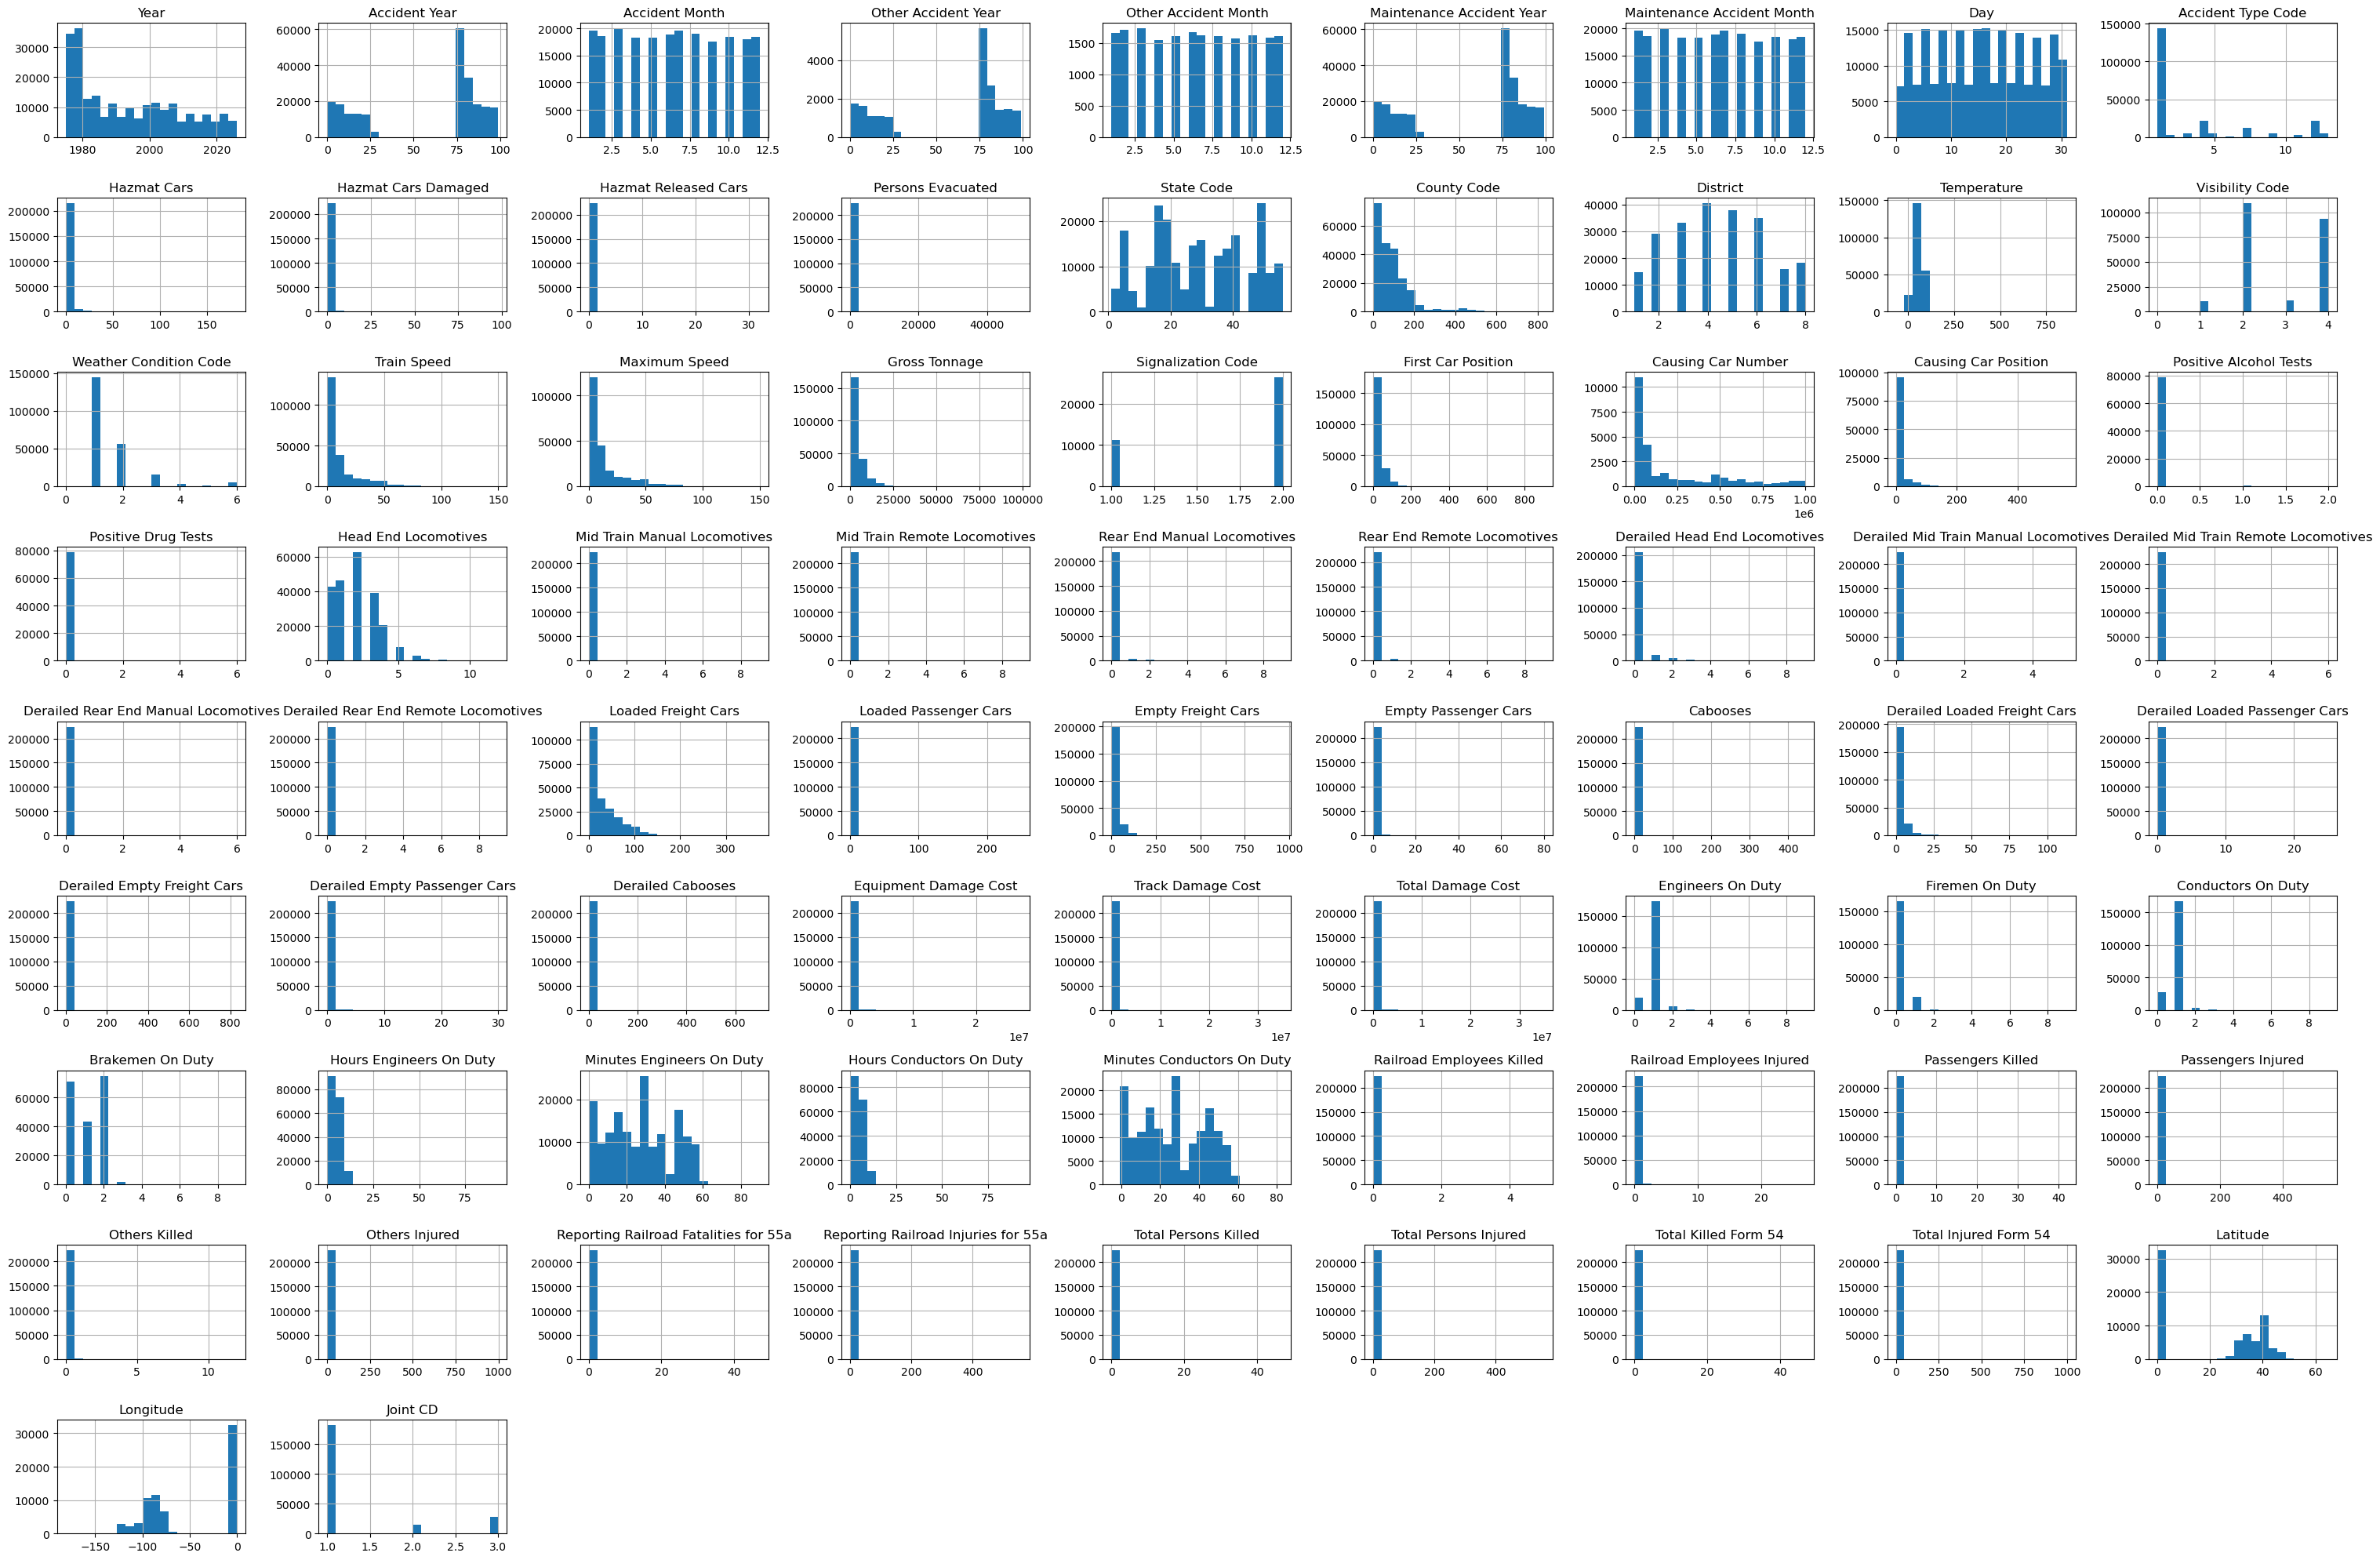

In [6]:
# Display distribution of numeric features
dist = df.hist(figsize=(30,20), bins = 20)
plt.tight_layout()
plt.show()

## Feature Selection

### Feature Name Correction

In [7]:
# Reformatting column names
# Turn columns to lowercase
df.columns = df.columns.str.lower()

# Remove space between columns
df.columns = df.columns.str.replace(" ","")
df.columns

Index(['reportingrailroadcode', 'reportingrailroadname', 'year',
       'accidentnumber', 'pdflink', 'accidentyear', 'accidentmonth',
       'otherrailroadcode', 'otherrailroadname', 'otheraccidentnumber',
       ...
       'reportingparentrailroadname', 'reportingrailroadholdingcompany',
       'reportingrailroadindividualclass', 'reportingrailroadpassenger',
       'reportingrailroadcommuter', 'reportingrailroadswitchingterminal',
       'reportingrailroadtourist', 'reportingrailroadfreight',
       'reportingrailroadshortline', 'location'],
      dtype='object', length=155)

### Duplicated Review

In [8]:
# Total number of duplicated values
df.duplicated().sum()

np.int64(5)

In [9]:
# Display duplicates
df[df.duplicated()]

,reportingrailroadcode,reportingrailroadname,year,accidentnumber,pdflink,accidentyear,accidentmonth,otherrailroadcode,otherrailroadname,otheraccidentnumber,otheraccidentyear,otheraccidentmonth,maintenancerailroadcode,maintenancerailroadname,maintenanceaccidentnumber,maintenanceaccidentyear,maintenanceaccidentmonth,gradecrossingid,day,date,time,accidenttypecode,accidenttype,hazmatcars,hazmatcarsdamaged,hazmatreleasedcars,personsevacuated,subdivision,divisioncode,division,station,milepost,statecode,stateabbreviation,statename,countycode,countyname,district,temperature,visibilitycode,visibility,weatherconditioncode,weathercondition,tracktypecode,tracktype,trackname,trackclass,trackdensity,traindirectioncode,traindirection,equipmenttypecode,equipmenttype,equipmentattended,trainnumber,trainspeed,recordedestimatedspeed,maximumspeed,grosstonnage,signalizationcode,signalization,methodofoperationcode,methodofoperation,adjunctcode1,adjunctname1,adjunctcode2,adjunctname2,adjunctcode3,adjunctname3,remotecontrollocomotivecode,remotecontrollocomotive,firstcarinitials,firstcarnumber,firstcarposition,firstcarloaded,causingcarinitials,causingcarnumber,causingcarposition,causingcarloaded,positivealcoholtests,positivedrugtests,passengerstransported,headendlocomotives,midtrainmanuallocomotives,midtrainremotelocomotives,rearendmanuallocomotives,rearendremotelocomotives,derailedheadendlocomotives,derailedmidtrainmanuallocomotives,derailedmidtrainremotelocomotives,derailedrearendmanuallocomotives,derailedrearendremotelocomotives,loadedfreightcars,loadedpassengercars,emptyfreightcars,emptypassengercars,cabooses,derailedloadedfreightcars,derailedloadedpassengercars,derailedemptyfreightcars,derailedemptypassengercars,derailedcabooses,equipmentdamagecost,trackdamagecost,totaldamagecost,primaryaccidentcausecode,primaryaccidentcause,contributingaccidentcausecode,contributingaccidentcause,accidentcausecode,accidentcause,engineersonduty,firemenonduty,conductorsonduty,brakemenonduty,hoursengineersonduty,minutesengineersonduty,hoursconductorsonduty,minutesconductorsonduty,railroademployeeskilled,railroademployeesinjured,passengerskilled,passengersinjured,otherskilled,othersinjured,reportingrailroadfatalitiesfor55a,reportingrailroadinjuriesfor55a,totalpersonskilled,totalpersonsinjured,totalkilledform54,totalinjuredform54,specialstudy1,specialstudy2,latitude,longitude,narrative,jointtracktype,jointtrackclass,classcode,class,jointcd,incidentkey,reportkey,reportingrailroadclass,reportingrailroadsmtgrouping,reportingparentrailroadcode,reportingparentrailroadname,reportingrailroadholdingcompany,reportingrailroadindividualclass,reportingrailroadpassenger,reportingrailroadcommuter,reportingrailroadswitchingterminal,reportingrailroadtourist,reportingrailroadfreight,reportingrailroadshortline,location
112779,UP,Union Pacific Railroad Company,1985,0885NP001,https://safetydata.fra.dot.gov/Officeofsafety/...,85,8,None,None,None,NaN,NaN,UP,Union Pacific Railroad Company,0885NP001,85.0,8.0,None,1,8/1/1985,10:30 AM,4,Side collision,0,0,0,0,None,NEBRAS,NEBRASKA,NORTH PLATTE,None,31,NE,NEBRASKA,111.0,LINCOLN,6,69,2.0,Day,2.0,Cloudy,2,Yard,FORWARDING TRACK,2,None,4,West,6,Cut of cars,No,CUT,0.0,Estimated,10.0,0,NaN,None,N,None,None,None,None,None,None,None,None,None,TTGX,962651,18.0,Yes,None,NaN,NaN,None,NaN,NaN,No,0,0,0,0,0,0,0,0,0,0,38,0,1,0,0,3,0,0,0,0,75000,0,368600,H306,"Shoving movement, absence of man on or at lead...",None,None,H306,"Shoving movement, absence of man on or at lead...",0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,0,0,0,0,0,0,1,0,1,0,0,None,None,NaN,NaN,SEE OTHER REPORTNoneNoneNoneNoneNoneNoneNoneNo...,Yard,2,1L,1L,3,UP0885NP001198508,UP0885NP001198508,Class I,SMT-6 - UP/KCS,UP,Union Pacific Railroad Company,Union Pacific Railroad Company,Class I,Unassigned,Unassigned,Unassigned,Unassigned,Yes,Unassigned,None
114965,UP,Union Pacific Railroad Company,1985,0885NP001,https://safetydata.fra.dot.gov/Officeofsafety/...,85,8,None,None,None,NaN,NaN,UP,Union Pacific Railroad 

In [10]:
# Remove duplicates due to identical ID numbers
df = df.drop_duplicates()
print(df.duplicated().sum())

0


### Missing Value Exploration

In [11]:
# Check missing values
# Reformat pd setup options
pd.set_option('display.max_rows', None)
missing_values = df.isnull().sum()
missing_values

reportingrailroadcode                      0
reportingrailroadname                      3
year                                       0
accidentnumber                             0
pdflink                                    4
accidentyear                               0
accidentmonth                              0
otherrailroadcode                     205201
otherrailroadname                     205256
otheraccidentnumber                   205194
otheraccidentyear                     205197
otheraccidentmonth                    205197
maintenancerailroadcode                    3
maintenancerailroadname                   89
maintenanceaccidentnumber                  2
maintenanceaccidentyear                    2
maintenanceaccidentmonth                   2
gradecrossingid                       212588
day                                        0
date                                       1
time                                       0
accidenttypecode                           0
accidentty

In [12]:
# Features with more then 25% of records being 'Null' were filter for analysis
missing_percent = df.isnull().sum() * 100 / len(df) # Missing values / total
df2 = pd.DataFrame({'Percent Missing': missing_percent}) # Seperate into features
percent_miss_df = df2[df2['Percent Missing'] > 10.0] # Slice the data that is over 10% missing
percent_miss_df

,Percent Missing
otherrailroadcode,91.322614
otherrailroadname,91.347091
otheraccidentnumber,91.319499
otheraccidentyear,91.320834
otheraccidentmonth,91.320834
gradecrossingid,94.610123
subdivision,83.281190
divisioncode,19.871473
division,18.568841
milepost,13.164278


In [13]:
# df['name'].value_counts() was used to analyze and determine solution
# Handle "Nulls" intensionally
df['positivealcoholtests'] = df['positivealcoholtests'].fillna(0.0)
df['positivedrugtests'] = df['positivedrugtests'].fillna(0.0)
df['equipmentattended'] = df['equipmentattended'].fillna('Unknown')
df['trainspeed'] = df['trainspeed'].fillna(df['trainspeed'].median())
df['passengerstransported'] = df['passengerstransported'].fillna('Unknown')

# Change data type found during exploration
df['district'] = df['district'].astype('str')
df['visibilitycode'] = df['visibilitycode'].astype('str')
df['weatherconditioncode'] = df['weatherconditioncode'].astype('str')

# Filter out "confusing" values
# Group_A
df = df[df['recordedestimatedspeed'].isin(['Estimated','Recorded'])]
df = df[df['accidenttype'] != 'Other (describe in narrative)']
df = df[(df['temperature'] < 110) & (df['temperature'] > -20)]
df = df[df['visibilitycode'] != 0.0]
df = df[df['loadedfreightcars'] <= 140]
df = df[df['emptyfreightcars'] <= 140]
df = df[df['emptypassengercars'] <= 20]
df = df[df['cabooses'] <= 5]

#Group_B
df = df[df['derailedloadedpassengercars'] <= 12]
df = df[df['derailedloadedfreightcars'] <= 50]
df = df[df['derailedrearendremotelocomotives'] <= 2]
df = df[df['derailedrearendmanuallocomotives'] <= 4]
df = df[df['derailedemptyfreightcars'] <= 40]
df = df[df['derailedemptypassengercars'] <= 6]
df = df[df['derailedcabooses'] <= 4]
df = df[df['hazmatcarsdamaged'] <= 20]
df = df[df['hazmatreleasedcars'] <= 7]
df = df[df['hazmatreleasedcars'] <= 7]
df = df[df['positivedrugtests'] <= 2.0]

# Fixing date features
drop_year = ['accidentyear']
# Drop columns from list and review shape
df = df.drop(columns = drop_year, errors = 'ignore')
df = df.rename(columns={'year': 'accidentyear'})
df = df.rename(columns={'day': 'accidentday'})

# Reformatting time into two columns for modeling
df['time'] = pd.to_datetime(df['time'], format = ('%I:%M %p'), errors = 'coerce') # Extra time formatting and convert unreadable values to NA
df['accidenthour'] = df['time'].dt.hour
df['accidentminute'] = df['time'].dt.minute

# Dropping the existing time column
df = df.drop(columns = 'time', axis =1)

### Column Description for Model Features

1) 'reportingrailroadcode': Code of the reporting railroad.
2) 'maintenancerailroadcode': Code of the railroad responsible for track maintenance.
3) 'accidentyear': Year of accident.
4) 'accidentmonth': Month of accident.
5) 'accidentday': Day of accident.
6) 'accidenthour': Hour accident took place.
7) 'accidentminute': Minute accident took place. 
8) 'accidenttype': Type of accident.
9) 'division': Railroad division.
10) 'stateabbreviation': Two letter abbreviation of state.
11) 'countyname': Name of county. 
12) 'district': FRA assigned geographical district.
13) 'hazmatcars': Number of hazmat cars involved. 
14) 'temperature': Temperature recorded at time of accident, in Fahrenheit.
15) 'visibilitycode': Visibility code recorded at time of accident.
16) 'visibility': Visibility recorded at time of accident.
17) 'weatherconditioncode': Weather condition code recorded at time of accident.
18) 'tracktype': Type of track.
19) 'grosstonnage': Trailing tons, gross tonnage, excluding power units.
20) 'passengerstransported': Yes/No if passengers were being transported. 
21) 'headendlocomotives': Number of head end locomotives.
22) 'midtrainmanuallocomotives': Number of mid train locomotives, manual.
23) 'midtrainremotelocomotives': Number of mid train locomotives, remote.
24) 'rearendmanuallocomotives': Number of rear end locomotives, manual.
25) 'rearendremotelocomotives': Number of rear end locomotives, remote.
26) 'loadedfreightcars': Number of loaded freight cars.
27) 'loadedpassengercars': Number of loaded passenger cars.
28) 'emptyfreightcars': Number of empty freight cars.
29) 'emptypassengercars': Number of empty passenger cars.
30) 'cabooses': Number of cabooses.  

### Dataframe Selection

In [14]:
# Claude AI was used for efficiency. Based on the provided prompt following prompt, gave advice on what features to seperate into each group.
# Further switching and adjustments where made based upon further investigation.
group = ['reportingrailroadcode',
         'maintenancerailroadcode',
         'accidentyear',
         'accidentmonth', 
         'accidentday',
         'accidenthour',
         'accidentminute',
         'accidenttype',
         'division', 
         'stateabbreviation',
         'countyname', 
         'district',
         'hazmatcars', 
         'temperature', 
         'visibilitycode', 
         'visibility',
         'weatherconditioncode', 
         'tracktype', 
         'grosstonnage',
         'passengerstransported',
         'headendlocomotives', 
         'midtrainmanuallocomotives',
         'midtrainremotelocomotives', 
         'rearendmanuallocomotives',
         'rearendremotelocomotives', 
         'loadedfreightcars',
         'loadedpassengercars', 
         'emptyfreightcars', 
         'emptypassengercars',
         'cabooses', 
         'equipmentdamagecost',
         'trackdamagecost',
         'totaldamagecost',
         'railroademployeeskilled',
         'railroademployeesinjured',
         'passengerskilled',
         'passengersinjured',
         'otherskilled',
         'othersinjured',
         'reportingrailroadfatalitiesfor55a',
         'reportingrailroadinjuriesfor55a',
         'totalpersonskilled',
         'totalpersonsinjured',
         'totalkilledform54',
         'totalinjuredform54',
         'derailedheadendlocomotives',
         'derailedmidtrainmanuallocomotives',
         'derailedmidtrainremotelocomotives',
         'derailedrearendmanuallocomotives',
         'derailedrearendremotelocomotives',
         'derailedloadedfreightcars',
         'derailedloadedpassengercars',
         'derailedemptyfreightcars',
         'derailedemptypassengercars',
         'derailedcabooses',
         'hazmatcarsdamaged',
         'hazmatreleasedcars',
         'personsevacuated',
         'positivealcoholtests', 
         'positivedrugtests']

# # Examining Group A
df = df[group]
df.head(5)

,reportingrailroadcode,maintenancerailroadcode,accidentyear,accidentmonth,accidentday,accidenthour,accidentminute,accidenttype,division,stateabbreviation,countyname,district,hazmatcars,temperature,visibilitycode,visibility,weatherconditioncode,tracktype,grosstonnage,passengerstransported,headendlocomotives,midtrainmanuallocomotives,midtrainremotelocomotives,rearendmanuallocomotives,rearendremotelocomotives,loadedfreightcars,loadedpassengercars,emptyfreightcars,emptypassengercars,cabooses,equipmentdamagecost,trackdamagecost,totaldamagecost,railroademployeeskilled,railroademployeesinjured,passengerskilled,passengersinjured,otherskilled,othersinjured,reportingrailroadfatalitiesfor55a,reportingrailroadinjuriesfor55a,totalpersonskilled,totalpersonsinjured,totalkilledform54,totalinjuredform54,derailedheadendlocomotives,derailedmidtrainmanuallocomotives,derailedmidtrainremotelocomotives,derailedrearendmanuallocomotives,derailedrearendremotelocomotives,derailedloadedfreightcars,derailedloadedpassengercars,derailedemptyfreightcars,derailedemptypassengercars,derailedcabooses,hazmatcarsdamaged,hazmatreleasedcars,personsevacuated,positivealcoholtests,positivedrugtests
0,CSX,CSX,2010,4,16,1.0,15.0,Derailment,ALBANY,NY,ALBANY,1,0,53,4.0,Dark,3.0,Yard,0,No,0,0,0,0,0,0,0,1,0,0,17189,1200,18389,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0.0,0.0
1,BNSF,BNSF,2010,12,24,16.0,30.0,Derailment,KANSAS,KS,COWLEY,6,0,35,2.0,Day,2.0,Main,14755,No,3,0,0,0,1,114,0,1,0,0,130746,450000,580746,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,11,0,0,0,0,0,0,0,0.0,0.0
2,RT,RT,1989,10,5,1.0,30.0,Derailment,SYSTEM,OH,CUYAHOGA,2,0,60,4.0,Dark,2.0,Yard,0,No,2,0,0,0,0,16,0,0,0,0,0,20000,20000,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,3,0,0,0,0,0,0,0,0.0,0.0
3,CO,CO,1983,6,14,23.0,45.0,Side collision,OHIO,OH,SENECA,2,0,70,4.0,Dark,1.0,Yard,0,No,0,0,0,0,0,34,0,2,0,0,10000,0,14000,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,2,0,0,0,0,0,0,0,0.0,0.0
4,BN,BN,1981,1,16,19.0,30.0,Rear end collision,DAKOTA,ND,CASS,8,0,5,4.0,Dark,2.0,Industry,0,No,0,0,0,0,0,0,0,4,0,0,0,0,13500,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.0,0.0


In [15]:
# Evaluate the new dataset missing values.
df.isnull().sum()

reportingrailroadcode                    0
maintenancerailroadcode                  2
accidentyear                             0
accidentmonth                            0
accidentday                              0
accidenthour                            32
accidentminute                          32
accidenttype                             0
division                             35932
stateabbreviation                        0
countyname                            3282
district                                 0
hazmatcars                               0
temperature                              0
visibilitycode                           0
visibility                             150
weatherconditioncode                     0
tracktype                             2120
grosstonnage                             0
passengerstransported                    0
headendlocomotives                       0
midtrainmanuallocomotives                0
midtrainremotelocomotives                0
rearendmanu

In [16]:
# Removed 'Null" records based on previous analysis
df = df.dropna()
# Double check work
df.shape

(159546, 60)

## Calculating Risk Score

### Train Test Split

In [17]:
# Split data
df_train, df_test, = train_test_split(df, test_size = 0.3, random_state = 42)

In [18]:
# Feature weights: assigned manually
feature_weights = {
        'equipmentdamagecost': 0.10, # Weight Reduced from 0.20
        'trackdamagecost': 0.10, # Weight Reduced from 0.20
        'totaldamagecost': 0.50, # Weight Increased from 0.50
        'railroademployeeskilled':0.50, # Weight Reduced from 0.90
        'railroademployeesinjured':0.30, # Weight Reduced from 0.50
        'passengerskilled':0.50, # Weight Reduced from 0.90
        'passengersinjured':0.30, # Weight Reduced from 0.50
        'otherskilled':0.50, # Weight Reduced from 0.90
        'othersinjured':0.30, # Weight Reduced from 0.50
        'reportingrailroadfatalitiesfor55a':0.30, # Weight Reduced from 0.90
        'reportingrailroadinjuriesfor55a':0.10, # Weight Reduced from 0.50
        'totalpersonskilled':0.60, # Weight Reduced from 0.90
        'totalpersonsinjured':0.50,
        'totalkilledform54':0.30, # Weight Reduced from 0.90
        'totalinjuredform54':0.20, # Weight Reduced from 0.50
        'derailedheadendlocomotives':0.35,
        'derailedmidtrainmanuallocomotives':0.35,
        'derailedmidtrainremotelocomotives':0.35,
        'derailedrearendmanuallocomotives':0.35,
        'derailedrearendremotelocomotives':0.35,
        'derailedloadedfreightcars':0.40,
        'derailedloadedpassengercars':0.50,
        'derailedemptyfreightcars':0.20,
        'derailedemptypassengercars':0.20,
        'derailedcabooses':0.20,
        'hazmatcarsdamaged':0.40,
        'hazmatreleasedcars':0.60, # Weight Reduced from 0.80
        'personsevacuated':0.30,
        'positivealcoholtests':0.50, 
        'positivedrugtests':0.50}

# Turn the dictionary into a usable list
feature_weights_list = list(feature_weights.keys())

**The heatmap below shows the correlation between features used in engineering the target variables. There is a strong positive correlation between features (e.g. equipmentdamagecost and totaldamagecost at 0.83). The information below was used to adjust the logic behind assigning the weights to each feature. Might need to re-evaluate whether keeping all features is necessary based on model performance. Want to investigate another method of assigning weights, so there is a solid methodology component behind it rather than a random assumption.**

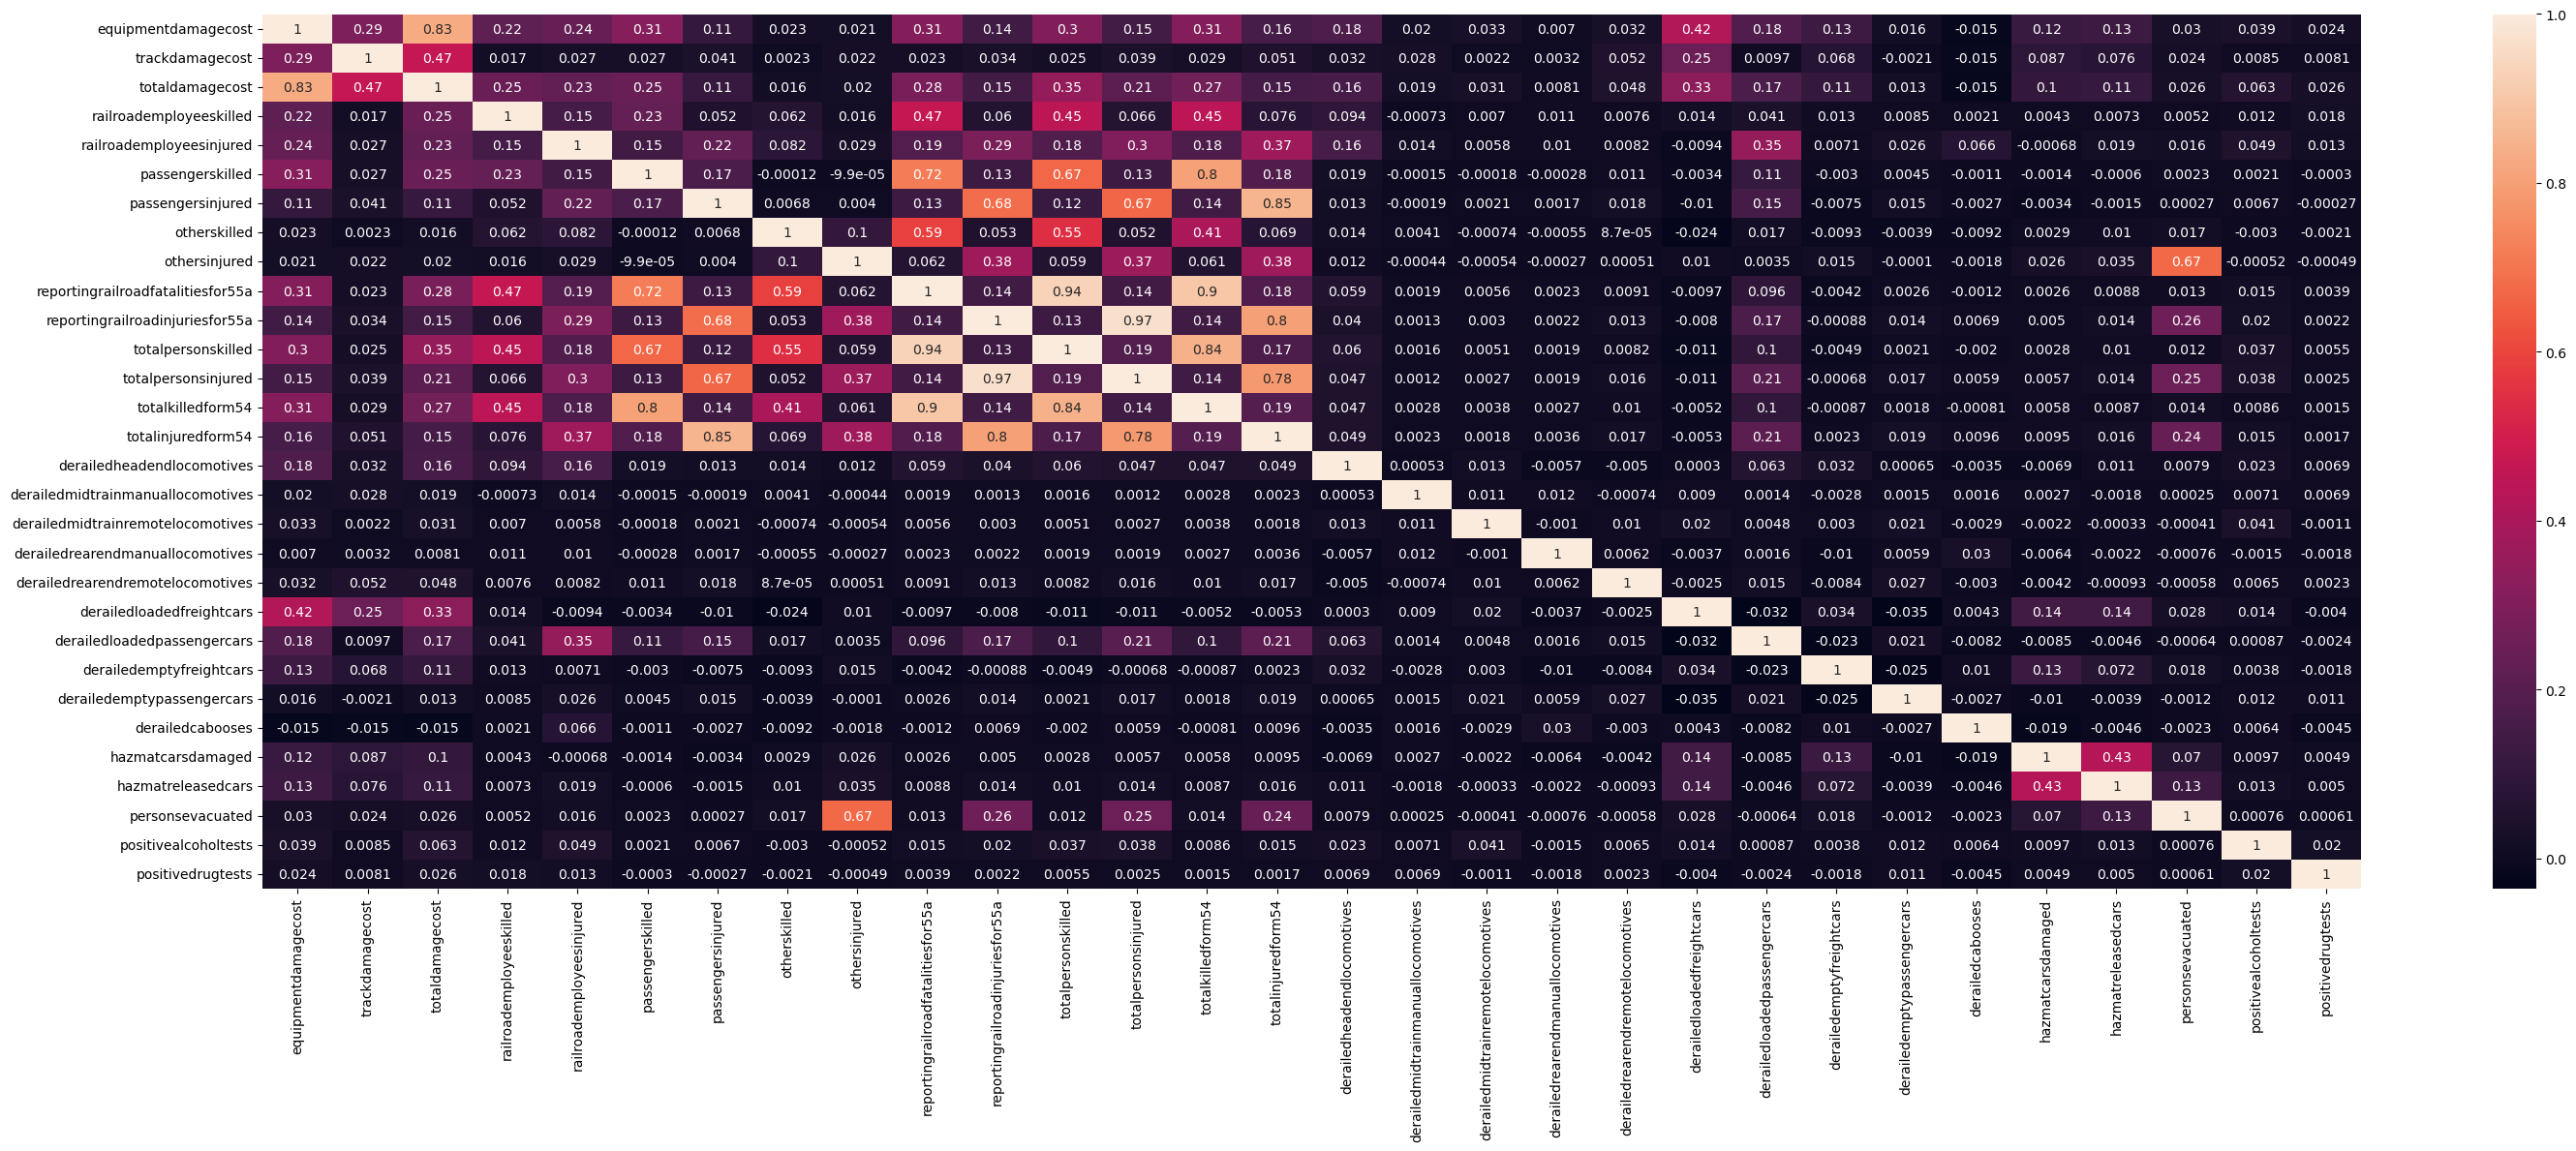

In [19]:
# Visual display of correlated features
plt.figure(figsize = (30,12))
heat_data = df_train[feature_weights_list].corr(numeric_only=True)
ax = sns.heatmap(heat_data, annot = True)
plt.tight_layout()

### Engineering Risk Score

**After evaluating the risk score manually, the question was asked whether calculating the risk score using the mean and standard deviation of the entire dataset poses data leakage.**

The following prompt was inserted in Claude AI:
*"If I calculated my risk score using the mean and standard deviation from the entire model to produce a z-score for each feature, that is then multiplied by its assigned weights and then summed all weighted z-scores per feature together for each record. Is this statistical engineering a possible data leak?"*

*Output: "Yes — there are actually two separate leakage risks tangled together in that approach, and it's worth separating them.*
1. Train/test leakage from using "the entire" dataset's mean/std.
2. Circularity between the target-construction features and your actual predictors."

In [20]:
# Claude AI was used to help trouble shoot logic.
# Calculate the mean and std based on the train set.
mean_cal = df_train[feature_weights_list].mean() # Calculated the mean of each column
std_cal = df_train[feature_weights_list].std().replace(0,1) # Calculated the std of each column. Replacing 0 with 1 helps prevent being divided by 0. 

# Calculate the 'Risk Score' for the train set.
train_z_score =(df_train[feature_weights_list] - mean_cal) / std_cal # Takes the value of X substract the calculated mean divided by the calculated std
train_weigth_series = pd.Series(feature_weights).reindex(train_z_score.columns).fillna(0) # Reindex weight dictionary to match order of z score
train_weighted = train_z_score.mul(train_weigth_series, axis = 1) # Take Z score and multiply it by it weights
df_train['risk_score'] = train_weighted.sum(axis=1) # Sum all weights together into one score

# Calculate the 'Risk Score' for the test set based on the mean and std calculated from train.
# Avoids data leaking. 
test_z_score =(df_test[feature_weights_list] - mean_cal) / std_cal
test_weigth_series = pd.Series(feature_weights).reindex(test_z_score.columns).fillna(0)
test_weighted = test_z_score.mul(test_weigth_series, axis = 1)
df_test['risk_score'] = test_weighted.sum(axis=1)

# Calculated column description
print("Train", df_train['risk_score'].describe())
print("Test:", df_test['risk_score'].describe())

Train count    1.116820e+05
mean     1.287708e-16
std      3.596079e+00
min     -1.121973e+00
25%     -9.636237e-01
50%     -7.077594e-01
75%     -1.681126e-01
max      5.039707e+02
Name: risk_score, dtype: float64
Test: count    47864.000000
mean         0.021381
std          3.406645
min         -1.121973
25%         -0.962138
50%         -0.706750
75%         -0.168939
max        290.331413
Name: risk_score, dtype: float64


**By using the probability plot, the calculated 'risk_score' along the y axis, in order from smallest to highest, is then compared to where the data would fall if normally distributed plot on the x-axis. The red line are the theoretical values where the data would fall. The plot shows that a large majority of the data share a similar value range, with outliers closer to the higher end bending the data points upward.**

Text(0.5, 1.0, 'Probability Plot on Test')

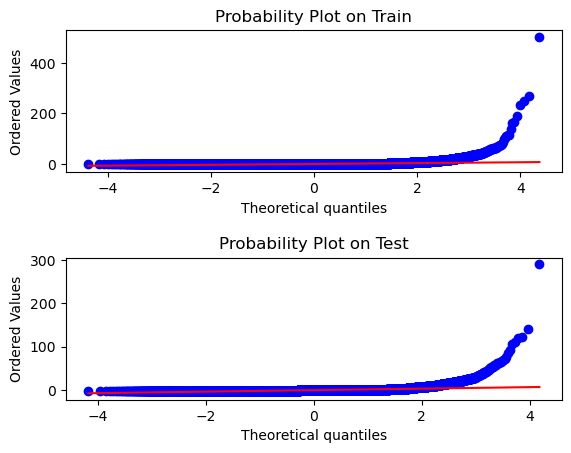

In [21]:
# Plot 'Risk Score' Probability
fig = plt.figure()
fig.subplots_adjust(hspace=0.6)
ax1 = fig.add_subplot(211)
ax2 = fig.add_subplot(212)
prob1 = stats.probplot(df_train['risk_score'], dist='norm', plot=ax1) # Creates a probability plot of data against a normal distribution. 
prob2 = stats.probplot(df_test['risk_score'], dist='norm', plot=ax2)
ax1.set_title('Probability Plot on Train')
ax2.set_title('Probability Plot on Test')

### Power Transformation

**After reviewing peer and professor recommendations, I decided to explore the Yeo-Johnson power transformation to correct the right skewness in the data to have a more normal distribution. It handles the zero and negative values well. It uses Lambda as a value to normalize the data distribution: values at 0 follow a log transformation, values at 1 experience no change in shape, and values at 2 stretch the data. Lambda is calculated automatically by minimizing the variance and skewness. Using PowerTransformer, the default standard scales the data. The probability plot shows that the middle portion of the data ordered by the y-axis follows the normal distribution line. The plot also shows that the data points produce an S-shape at both ends, hinting that there are repeating values.**

In [22]:
# Implement Power Transformation
transformer = PowerTransformer(method='yeo-johnson') # Standardize data by default
df_train['risk_score_yeo'] = transformer.fit_transform(df_train[['risk_score']]) # Fit on the training data
df_test['risk_score_yeo'] = transformer.transform(df_test[['risk_score']]) # Apply transformation onto testing data

In [23]:
# Calculated column description
print("Train", df_train['risk_score_yeo'].describe())
print("Test:", df_test['risk_score_yeo'].describe())

Train count    1.116820e+05
mean     6.082259e-17
std      1.000004e+00
min     -1.370754e+00
25%     -8.669798e-01
50%     -1.856363e-01
75%      7.755079e-01
max      2.378755e+00
Name: risk_score_yeo, dtype: float64
Test: count    47864.000000
mean         0.002999
std          1.000759
min         -1.370754
25%         -0.862560
50%         -0.183256
75%          0.774473
max          2.368850
Name: risk_score_yeo, dtype: float64


Text(0.5, 1.0, 'Probability Plot on Test After Yeo-Johnson')

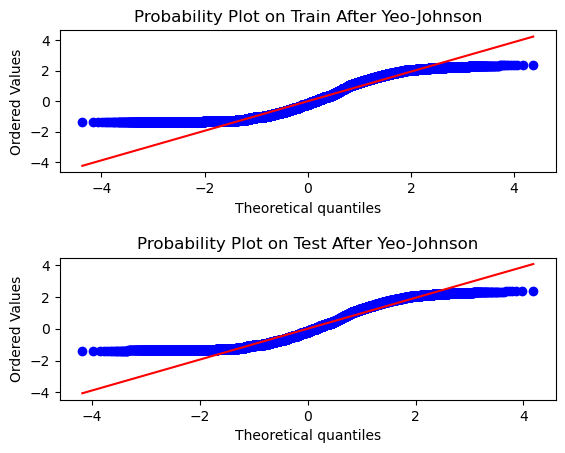

In [24]:
# Plot 'Risk Score' after transformation
fig = plt.figure()
fig.subplots_adjust(hspace=0.6)
ax1 = fig.add_subplot(211)
ax2 = fig.add_subplot(212)
prob1 = stats.probplot(df_train['risk_score_yeo'], dist='norm', plot=ax1)
prob2 = stats.probplot(df_test['risk_score_yeo'], dist='norm', plot=ax2)
ax1.set_title('Probability Plot on Train After Yeo-Johnson')
ax2.set_title('Probability Plot on Test After Yeo-Johnson')

### Applying CDF

**To generate a score, CDF was used because it transforms normally distributed data into a 0-1 range. The value is then multiplied by 100 to generate a percentage. The logic behind the 'risk_percent' is not "This accident is 75% risk." Instead, it is read as "This accident risk is higher than 75% of all other risks in the dataset." However, the histograms below demonstrate the S-shaped pattern in the probability plots. Therefore, as they do not follow the line hinting at normal distribution, their percentages could be argued as less accurate.**

In [25]:
# Create a percentile based on CDF
df_train['risk_percent'] = stats.norm.cdf(df_train['risk_score_yeo']) * 100
df_test['risk_percent'] = stats.norm.cdf(df_test['risk_score_yeo']) * 100

# Display results
risk = df_train['risk_percent']
risk2 = df_test['risk_percent']
print("Train:", risk.describe())
print("Test:", risk2.describe())

Train: count    111682.000000
mean         48.287061
std          30.454696
min           8.522576
25%          19.297655
50%          42.636498
75%          78.098020
max          99.131439
Name: risk_percent, dtype: float64
Test: count    47864.000000
mean        48.366668
std         30.447113
min          8.522576
25%         19.418963
50%         42.729847
75%         78.067458
max         99.107825
Name: risk_percent, dtype: float64


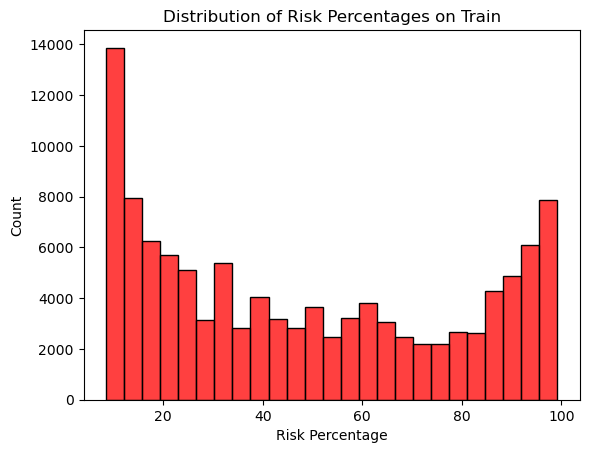

In [26]:
# Train set percentage distribution
sns.histplot(data = df_train, x=risk, color = 'red', edgecolor = 'black', bins = 25)
plt.title('Distribution of Risk Percentages on Train')
plt.xlabel('Risk Percentage')
plt.ylabel('Count')
plt.show()

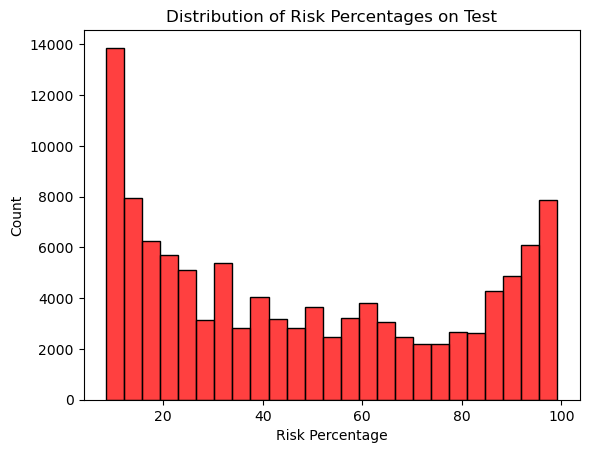

In [27]:
# Test set percentage distribution
sns.histplot(data = df_test, x=risk, color = 'red', edgecolor = 'black', bins = 25)
plt.title('Distribution of Risk Percentages on Test')
plt.xlabel('Risk Percentage')
plt.ylabel('Count')
plt.show()

## Calculating Financial and Legal

In [28]:
# Copied and manually filtered based on previous weight feature dictionary
fin_weights = {
        'equipmentdamagecost': 0.10, # Weight Reduced from 0.20
        'trackdamagecost': 0.10, # Weight Reduced from 0.20
        'totaldamagecost': 0.50, # Weight Increased from 0.50
}
# Turn the dictionary into a usable list
fin_weights_list = list(fin_weights.keys())

leg_weights = {
        'railroademployeeskilled':0.50, # Weight Reduced from 0.90
        'railroademployeesinjured':0.30, # Weight Reduced from 0.50
        'passengerskilled':0.50, # Weight Reduced from 0.90
        'passengersinjured':0.30, # Weight Reduced from 0.50
        'otherskilled':0.50, # Weight Reduced from 0.90
        'othersinjured':0.30, # Weight Reduced from 0.50
        'reportingrailroadfatalitiesfor55a':0.30, # Weight Reduced from 0.90
        'reportingrailroadinjuriesfor55a':0.10, # Weight Reduced from 0.50
        'totalpersonskilled':0.60, # Weight Reduced from 0.90
        'totalpersonsinjured':0.50,
        'totalkilledform54':0.30, # Weight Reduced from 0.90
        'totalinjuredform54':0.20, # Weight Reduced from 0.50
        'derailedheadendlocomotives':0.35,
        'derailedmidtrainmanuallocomotives':0.35,
        'derailedmidtrainremotelocomotives':0.35,
        'derailedrearendmanuallocomotives':0.35,
        'derailedrearendremotelocomotives':0.35,
        'derailedloadedfreightcars':0.40,
        'derailedloadedpassengercars':0.50,
        'derailedemptyfreightcars':0.20,
        'derailedemptypassengercars':0.20,
        'derailedcabooses':0.20,
        'hazmatcarsdamaged':0.40,
        'hazmatreleasedcars':0.60, # Weight Reduced from 0.80
        'personsevacuated':0.30,
        'positivealcoholtests':0.50, 
        'positivedrugtests':0.50
}

# Turn the dictionary into a usable list
leg_weights_list = list(leg_weights.keys())

#### Financial Risk

In [29]:
# Finanical Risk score
mean_cal = df_train[fin_weights_list].mean() # Calculated the mean of each column.
std_cal = df_train[fin_weights_list].std().replace(0,1) # Calculated the std of each column. Replacing 0 with 1 helps prevent being divided by 0. 

fin_z_score =(df_train[fin_weights_list] - mean_cal) / std_cal # Takes the value of X substract the calculated mean divided by the calculated std.
fin_weigth_series = pd.Series(fin_weights).reindex(fin_z_score.columns).fillna(0) # Reindex weight dictionary to match order of z score.
fin_weighted = fin_z_score.mul(fin_weigth_series, axis = 1) # Take Z score and multiply it by it weights.
df_train['fin_score'] = fin_weighted.sum(axis=1) # Sum all weights together into one score.

fin_z_score =(df_test[fin_weights_list] - mean_cal) / std_cal 
fin_weigth_series = pd.Series(fin_weights).reindex(fin_z_score.columns).fillna(0) 
fin_weighted = fin_z_score.mul(fin_weigth_series, axis = 1) 
df_test['fin_score'] = fin_weighted.sum(axis=1) 

# Calculated Column Description
print("Train", df_train['fin_score'].describe())
print("Test:", df_test['fin_score'].describe())

Train count    1.116820e+05
mean     6.425818e-18
std      6.366458e-01
min     -1.759373e-01
25%     -1.547789e-01
50%     -1.345056e-01
75%     -7.138202e-02
max      3.360919e+01
Name: fin_score, dtype: float64
Test: count    47864.000000
mean         0.000488
std          0.701247
min         -0.175937
25%         -0.154421
50%         -0.134222
75%         -0.070359
max         56.759115
Name: fin_score, dtype: float64


Text(0.5, 1.0, 'Probability Plot on Test')

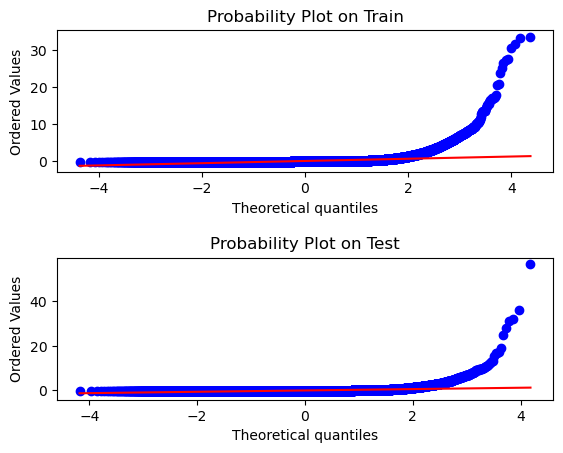

In [30]:
# Plot Financial Risk Score
fig = plt.figure()
fig.subplots_adjust(hspace=0.6)
ax1 = fig.add_subplot(211)
ax2 = fig.add_subplot(212)
prob1 = stats.probplot(df_train['fin_score'], dist='norm', plot=ax1)
prob2 = stats.probplot(df_test['fin_score'], dist='norm', plot=ax2)
ax1.set_title('Probability Plot on Train')
ax2.set_title('Probability Plot on Test')

In [31]:
# Implement Power Transformation
transformer = PowerTransformer(method='yeo-johnson')
df_train['risk_fin_yeo'] = transformer.fit_transform(df_train[['fin_score']])
df_test['risk_fin_yeo'] = transformer.transform(df_test[['fin_score']])

# Calculated column description
print("Train", df_train['risk_fin_yeo'].describe())
print("Test:", df_test['risk_fin_yeo'].describe())

Train count    1.116820e+05
mean    -1.068849e-17
std      1.000004e+00
min     -1.223394e+00
25%     -7.667892e-01
50%     -3.833145e-01
75%      5.309680e-01
max      2.287773e+00
Name: risk_fin_yeo, dtype: float64
Test: count    47864.000000
mean         0.005597
std          0.996851
min         -1.223394
25%         -0.759583
50%         -0.378306
75%          0.542826
max          2.287773
Name: risk_fin_yeo, dtype: float64


Text(0.5, 1.0, 'Probability Plot on Test After Yeo-Johnson')

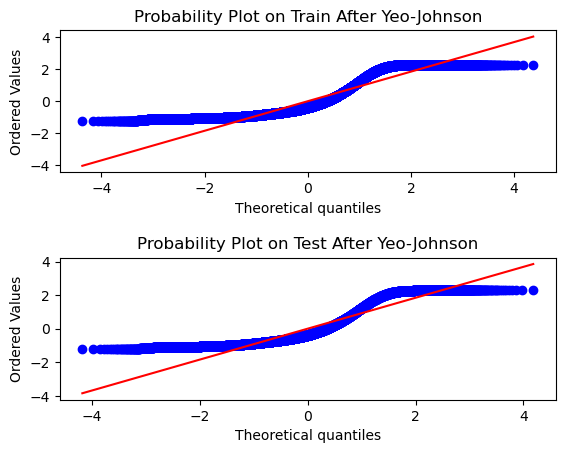

In [32]:
# Plot Financial Risk Score after transformation
fig = plt.figure()
fig.subplots_adjust(hspace=0.6)
ax1 = fig.add_subplot(211)
ax2 = fig.add_subplot(212)
prob1 = stats.probplot(df_train['risk_fin_yeo'], dist='norm', plot=ax1)
prob2 = stats.probplot(df_test['risk_fin_yeo'], dist='norm', plot=ax2)
ax1.set_title('Probability Plot on Train After Yeo-Johnson')
ax2.set_title('Probability Plot on Test After Yeo-Johnson')

In [33]:
# Create a percentile based on CDF
df_train['fin_percent'] = stats.norm.cdf(df_train['risk_fin_yeo']) * 100
df_test['fin_percent'] = stats.norm.cdf(df_test['risk_fin_yeo']) * 100

# Display results
fin = df_train['fin_percent']
fin2 = df_test['fin_percent']
print("Train:", risk.describe())
print("Test:", risk2.describe())

Train: count    111682.000000
mean         48.287061
std          30.454696
min           8.522576
25%          19.297655
50%          42.636498
75%          78.098020
max          99.131439
Name: risk_percent, dtype: float64
Test: count    47864.000000
mean        48.366668
std         30.447113
min          8.522576
25%         19.418963
50%         42.729847
75%         78.067458
max         99.107825
Name: risk_percent, dtype: float64


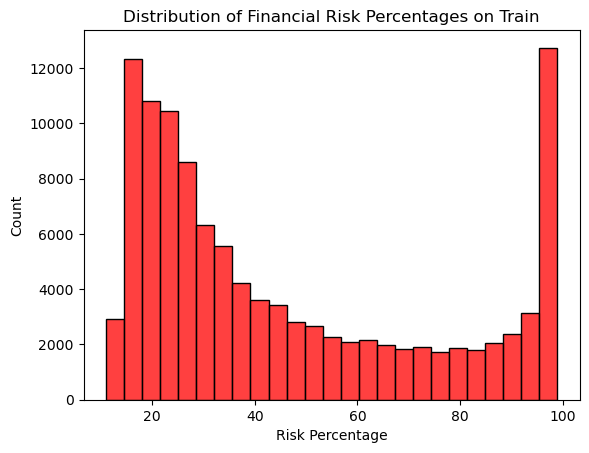

In [34]:
# Train set percentage distribution
sns.histplot(data = df_train, x=fin, color = 'red', edgecolor = 'black', bins = 25)
plt.title('Distribution of Financial Risk Percentages on Train')
plt.xlabel('Risk Percentage')
plt.ylabel('Count')
plt.show()

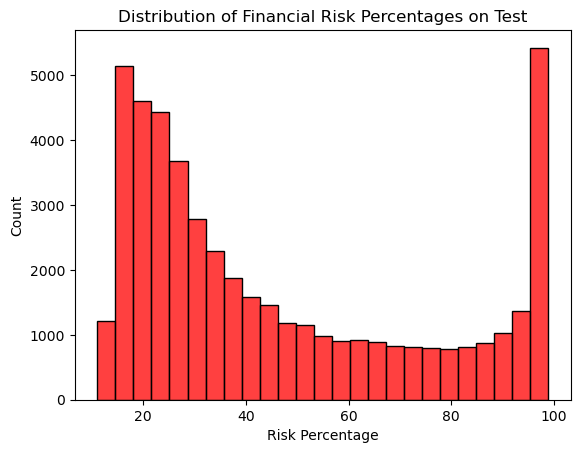

In [35]:
# Test set percentage distribution
sns.histplot(data = df_test, x=fin2, color = 'red', edgecolor = 'black', bins = 25)
plt.title('Distribution of Financial Risk Percentages on Test')
plt.xlabel('Risk Percentage')
plt.ylabel('Count')
plt.show()

#### Legal Risk

In [36]:
mean_cal = df_train[leg_weights_list].mean() # Calculated the mean of each column
std_cal = df_train[leg_weights_list].std().replace(0,1) # Calculated the std of each column. Replacing 0 with 1 helps prevent being divided by 0. 

leg_z_score =(df_train[leg_weights_list] - mean_cal) / std_cal # Takes the value of X substract the calculated mean divided by the calculated std
leg_weigth_series = pd.Series(leg_weights).reindex(leg_z_score.columns).fillna(0) # Reindex weight dictionary to match order of z score
leg_weighted = leg_z_score.mul(leg_weigth_series, axis = 1) # Take Z score and multiply it by it weights
df_train['leg_score'] = leg_weighted.sum(axis=1) # Sum all weights together into one score

leg_z_score =(df_test[leg_weights_list] - mean_cal) / std_cal # Takes the value of X substract the calculated mean divided by the calculated std
leg_weigth_series = pd.Series(leg_weights).reindex(leg_z_score.columns).fillna(0) # Reindex weight dictionary to match order of z score
leg_weighted = leg_z_score.mul(leg_weigth_series, axis = 1) # Take Z score and multiply it by it weights
df_test['leg_score'] = leg_weighted.sum(axis=1) # Sum all weights together into one score

# Calculated column description
print("Train", df_train['leg_score'].describe())
print("Test:", df_test['leg_score'].describe())

Train count    1.116820e+05
mean     8.550791e-17
std      3.283904e+00
min     -9.460359e-01
25%     -8.531698e-01
50%     -5.843783e-01
75%     -1.677359e-01
max      4.724537e+02
Name: leg_score, dtype: float64
Test: count    47864.000000
mean         0.020893
std          3.025541
min         -0.946036
25%         -0.853170
50%         -0.586018
75%         -0.172828
max        254.252610
Name: leg_score, dtype: float64


Text(0.5, 1.0, 'Probability Plot on Test')

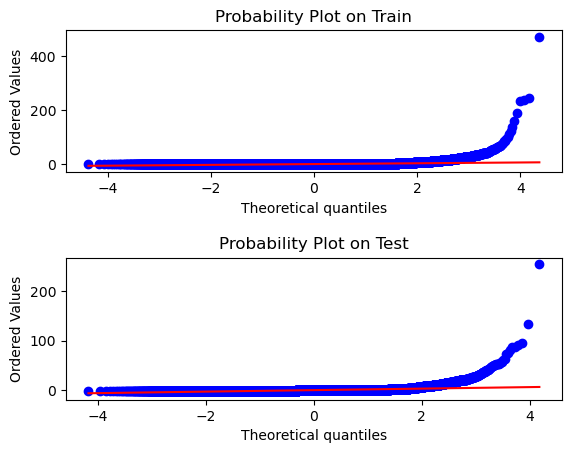

In [37]:
# Plot Legal Risk Score
fig = plt.figure()
fig.subplots_adjust(hspace=0.6)
ax1 = fig.add_subplot(211)
ax2 = fig.add_subplot(212)
prob1 = stats.probplot(df_train['leg_score'], dist='norm', plot=ax1)
prob2 = stats.probplot(df_test['leg_score'], dist='norm', plot=ax2)
ax1.set_title('Probability Plot on Train')
ax2.set_title('Probability Plot on Test')

In [38]:
# Implement power transformation
transformer = PowerTransformer(method='yeo-johnson')
df_train['risk_leg_yeo'] = transformer.fit_transform(df_train[['leg_score']])
df_test['risk_leg_yeo'] = transformer.transform(df_test[['leg_score']])

# Calculated column description
print("Train", df_train['risk_leg_yeo'].describe())
print("Test:", df_test['risk_leg_yeo'].describe())

Train count    1.116820e+05
mean    -1.819588e-17
std      1.000004e+00
min     -1.250016e+00
25%     -9.167602e-01
50%     -1.101992e-01
75%      7.306555e-01
max      2.348349e+00
Name: risk_leg_yeo, dtype: float64
Test: count    47864.000000
mean         0.001185
std          1.001827
min         -1.250016
25%         -0.916760
50%         -0.114445
75%          0.723022
max          2.341881
Name: risk_leg_yeo, dtype: float64


Text(0.5, 1.0, 'Probability Plot on Test')

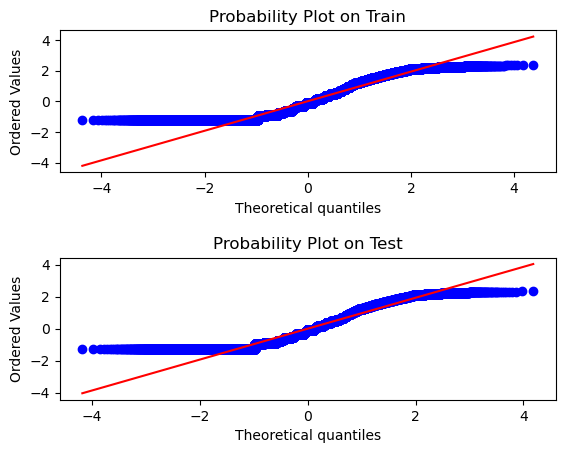

In [39]:
# Plot Legal Risk Score after transformation
fig = plt.figure()
fig.subplots_adjust(hspace=0.6)
ax1 = fig.add_subplot(211)
ax2 = fig.add_subplot(212)
prob1 = stats.probplot(df_train['risk_leg_yeo'], dist='norm', plot=ax1)
prob2 = stats.probplot(df_test['risk_leg_yeo'], dist='norm', plot=ax2)
ax1.set_title('Probability Plot on Train')
ax2.set_title('Probability Plot on Test')

In [40]:
# Create a percentile based on CDF
df_train['leg_percent'] = stats.norm.cdf(df_train['risk_leg_yeo']) * 100
df_test['leg_percent'] = stats.norm.cdf(df_test['risk_leg_yeo']) * 100

# Display result
leg = df_train['leg_percent']
leg2 = df_test['leg_percent']
print("Train:", leg.describe())
print("Test:", leg2.describe())

Train: count    111682.000000
mean         48.377435
std          30.471423
min          10.564693
25%          17.963417
50%          45.612570
75%          76.750519
max          99.057158
Name: leg_percent, dtype: float64
Test: count    47864.000000
mean        48.377356
std         30.484909
min         10.564693
25%         17.963417
50%         45.444270
75%         76.516675
max         99.040659
Name: leg_percent, dtype: float64


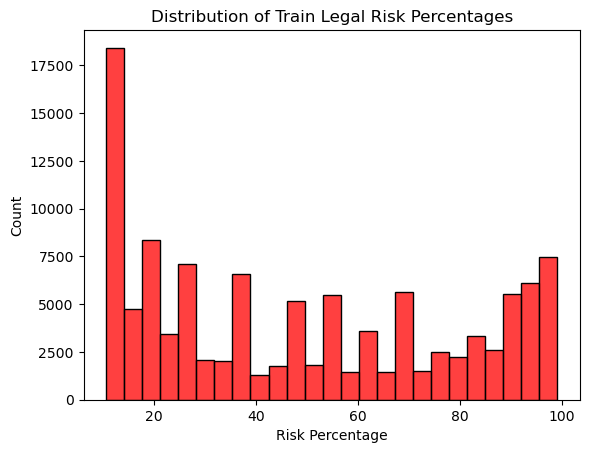

In [41]:
# Train set percentage distribution
sns.histplot(data = df_train, x=leg, color = 'red', edgecolor = 'black', bins = 25)
plt.title('Distribution of Train Legal Risk Percentages')
plt.xlabel('Risk Percentage')
plt.ylabel('Count')
plt.show()

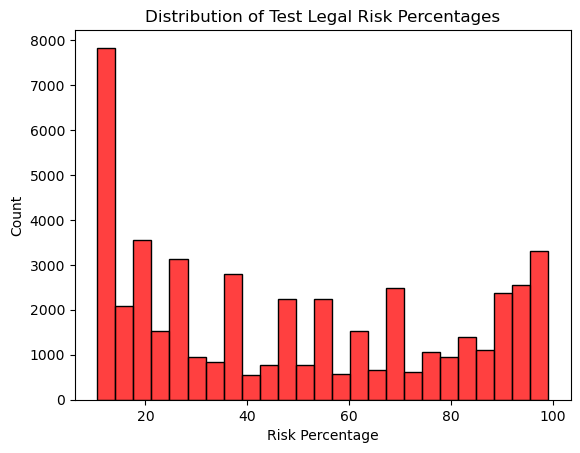

In [42]:
# Test set percentage distribution
sns.histplot(data = df_test, x=leg2, color = 'red', edgecolor = 'black', bins = 25)
plt.title('Distribution of Test Legal Risk Percentages')
plt.xlabel('Risk Percentage')
plt.ylabel('Count')
plt.show()

**A manual limit per group was set at 50%. For each record, if 'fin_percent' or 'leg_percent' is greater then 50%, it will classify the risk category toward that score. If both are present, then it will fall under 'Combination Risk.'**

In [43]:
# Claude AI was used to trouble shoot logic from previous version - streamline the code 
def risk_category(x):
    fin_eval = x['fin_percent'] >= 50.0
    leg_pres = x['leg_percent'] >= 50.0

    if fin_eval and leg_pres:
        return 'Combination Risk'
    elif fin_eval and not leg_pres:
        return 'Financial Risk'
    elif not fin_eval and leg_pres:
        return 'Legal Risk'
    else:
        return 'Minimal Risk'

# Add 'risk_category' to dataframe
df_train['risk_category'] = df_train.apply(risk_category, axis=1)
df_test['risk_category'] = df_test.apply(risk_category, axis=1)

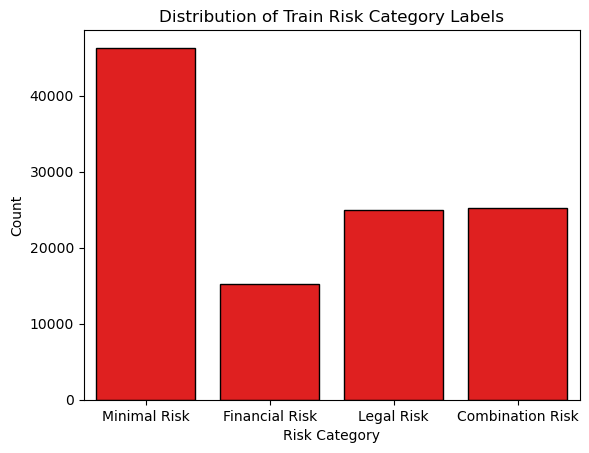

In [44]:
x_order = ['Minimal Risk','Financial Risk','Legal Risk','Combination Risk']
sns.countplot(df_train, x='risk_category', color = 'red', edgecolor = 'black', order = x_order)
plt.title('Distribution of Train Risk Category Labels')
plt.xlabel('Risk Category')
plt.ylabel('Count')
plt.show()

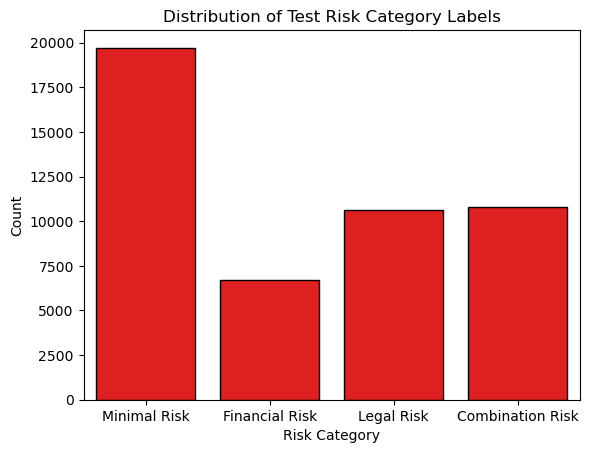

In [45]:
sns.countplot(df_test, x='risk_category', color = 'red', edgecolor = 'black', order = x_order)
plt.title('Distribution of Test Risk Category Labels')
plt.xlabel('Risk Category')
plt.ylabel('Count')
plt.show()

In [46]:
df_train.head(3)

,reportingrailroadcode,maintenancerailroadcode,accidentyear,accidentmonth,accidentday,accidenthour,accidentminute,accidenttype,division,stateabbreviation,countyname,district,hazmatcars,temperature,visibilitycode,visibility,weatherconditioncode,tracktype,grosstonnage,passengerstransported,headendlocomotives,midtrainmanuallocomotives,midtrainremotelocomotives,rearendmanuallocomotives,rearendremotelocomotives,loadedfreightcars,loadedpassengercars,emptyfreightcars,emptypassengercars,cabooses,equipmentdamagecost,trackdamagecost,totaldamagecost,railroademployeeskilled,railroademployeesinjured,passengerskilled,passengersinjured,otherskilled,othersinjured,reportingrailroadfatalitiesfor55a,reportingrailroadinjuriesfor55a,totalpersonskilled,totalpersonsinjured,totalkilledform54,totalinjuredform54,derailedheadendlocomotives,derailedmidtrainmanuallocomotives,derailedmidtrainremotelocomotives,derailedrearendmanuallocomotives,derailedrearendremotelocomotives,derailedloadedfreightcars,derailedloadedpassengercars,derailedemptyfreightcars,derailedemptypassengercars,derailedcabooses,hazmatcarsdamaged,hazmatreleasedcars,personsevacuated,positivealcoholtests,positivedrugtests,risk_score,risk_score_yeo,risk_percent,fin_score,risk_fin_yeo,fin_percent,leg_score,risk_leg_yeo,leg_percent,risk_category
121524,SCL,SCL,1981,11,13,19.0,40.0,Derailment,SAVANNAH,AL,MONTGOMERY,3,1,50,4.0,Dark,1.0,Yard,2140,No,2,0,0,0,0,16,0,18,0,1,17300,350,17650,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,4,0,1,0,0,1,1,0,0.0,0.0,3.100801,1.841746,96.724387,-0.126573,-0.246402,40.268557,3.227374,1.915027,97.225550,Legal Risk
133059,RI,RI,1979,4,1,12.0,50.0,Derailment,ILLINOIS,IA,LINN,6,0,40,2.0,Day,2.0,Main,9032,No,4,0,0,0,0,68,0,2,0,1,6860,3460,10320,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,1,0,1,0,1,0,0,0,0.0,0.0,0.917751,1.470360,92.926791,-0.143822,-0.553348,29.001264,1.061573,1.569859,94.177604,Legal Risk
15257,CNW,CNW,1984,5,7,13.0,30.0,Side collision,CENTRAL,IA,WRIGHT,6,0,50,2.0,Day,2.0,Yard,0,No,1,0,0,0,0,0,0,7,0,0,11408,550,12058,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,2,0,0,0,0,0,0.0,0.0,-0.943997,-0.809032,20.924824,-0.141969,-0.518712,30.198094,-0.802029,-0.745596,22.795573,Minimal Risk


In [47]:
df_test.head(3)

,reportingrailroadcode,maintenancerailroadcode,accidentyear,accidentmonth,accidentday,accidenthour,accidentminute,accidenttype,division,stateabbreviation,countyname,district,hazmatcars,temperature,visibilitycode,visibility,weatherconditioncode,tracktype,grosstonnage,passengerstransported,headendlocomotives,midtrainmanuallocomotives,midtrainremotelocomotives,rearendmanuallocomotives,rearendremotelocomotives,loadedfreightcars,loadedpassengercars,emptyfreightcars,emptypassengercars,cabooses,equipmentdamagecost,trackdamagecost,totaldamagecost,railroademployeeskilled,railroademployeesinjured,passengerskilled,passengersinjured,otherskilled,othersinjured,reportingrailroadfatalitiesfor55a,reportingrailroadinjuriesfor55a,totalpersonskilled,totalpersonsinjured,totalkilledform54,totalinjuredform54,derailedheadendlocomotives,derailedmidtrainmanuallocomotives,derailedmidtrainremotelocomotives,derailedrearendmanuallocomotives,derailedrearendremotelocomotives,derailedloadedfreightcars,derailedloadedpassengercars,derailedemptyfreightcars,derailedemptypassengercars,derailedcabooses,hazmatcarsdamaged,hazmatreleasedcars,personsevacuated,positivealcoholtests,positivedrugtests,risk_score,risk_score_yeo,risk_percent,fin_score,risk_fin_yeo,fin_percent,leg_score,risk_leg_yeo,leg_percent,risk_category
146877,MP,MP,1979,9,20,14.0,45.0,Derailment,KANSAS,KS,RUSH,6,0,80,2.0,Day,1.0,Main,4909,No,2,0,0,0,0,51,0,15,0,0,18400,25000,43400,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,13,0,4,0,0,0,0,0,0.0,0.0,0.518799,1.312936,90.539780,-0.030440,0.945329,82.775448,0.549238,1.366864,91.416609,Combination Risk
129942,UP,UP,1980,6,19,11.0,15.0,Rear end collision,NEBRASKA,NE,LINCOLN,6,0,63,2.0,Day,3.0,Yard,0,No,1,0,0,0,0,17,0,0,0,0,350,5743,6093,0,1,0,0,0,0,0,1,0,1,0,0,0,0,0,0,0,2,0,0,0,0,0,0,0,0.0,0.0,-0.054415,0.906389,81.763500,-0.153280,-0.736695,23.065400,0.098865,1.052498,85.371448,Legal Risk
182668,MILW,MILW,1976,12,5,2.0,0.0,Derailment,IOWA,IA,WAPELLO,6,0,19,4.0,Dark,2.0,Siding,4939,No,6,0,0,0,0,38,0,59,0,1,16950,4000,27900,0,0,0,0,0,0,0,0,0,0,0,0,3,0,0,0,0,3,0,8,0,0,0,0,0,0.0,0.0,1.652949,1.652237,95.075687,-0.099087,0.176491,57.004599,1.752036,1.732887,95.844209,Combination Risk


### Dropping Feature Engineering Columns

In [48]:
drop_list = ['equipmentdamagecost', 'trackdamagecost',
       'totaldamagecost', 'railroademployeeskilled',
       'railroademployeesinjured', 'passengerskilled', 'passengersinjured',
       'otherskilled', 'othersinjured', 'reportingrailroadfatalitiesfor55a',
       'reportingrailroadinjuriesfor55a', 'totalpersonskilled',
       'totalpersonsinjured', 'totalkilledform54', 'totalinjuredform54',
       'derailedheadendlocomotives', 'derailedmidtrainmanuallocomotives',
       'derailedmidtrainremotelocomotives', 'derailedrearendmanuallocomotives',
       'derailedrearendremotelocomotives', 'derailedloadedfreightcars',
       'derailedloadedpassengercars', 'derailedemptyfreightcars',
       'derailedemptypassengercars', 'derailedcabooses', 'hazmatcarsdamaged',
       'hazmatreleasedcars', 'personsevacuated', 'positivealcoholtests',
       'positivedrugtests', 'risk_score',
       'risk_score_yeo', 'fin_score', 'risk_fin_yeo',
       'fin_percent', 'leg_score', 'risk_leg_yeo', 'leg_percent']

In [49]:
df_train = df_train.drop(columns = drop_list, axis=1)
df_test = df_test.drop(columns = drop_list, axis=1)
df_train.columns

Index(['reportingrailroadcode', 'maintenancerailroadcode', 'accidentyear',
       'accidentmonth', 'accidentday', 'accidenthour', 'accidentminute',
       'accidenttype', 'division', 'stateabbreviation', 'countyname',
       'district', 'hazmatcars', 'temperature', 'visibilitycode', 'visibility',
       'weatherconditioncode', 'tracktype', 'grosstonnage',
       'passengerstransported', 'headendlocomotives',
       'midtrainmanuallocomotives', 'midtrainremotelocomotives',
       'rearendmanuallocomotives', 'rearendremotelocomotives',
       'loadedfreightcars', 'loadedpassengercars', 'emptyfreightcars',
       'emptypassengercars', 'cabooses', 'risk_percent', 'risk_category'],
      dtype='object')

## EDA and Summary Statistics

### Train Data Distribution

### Train Set

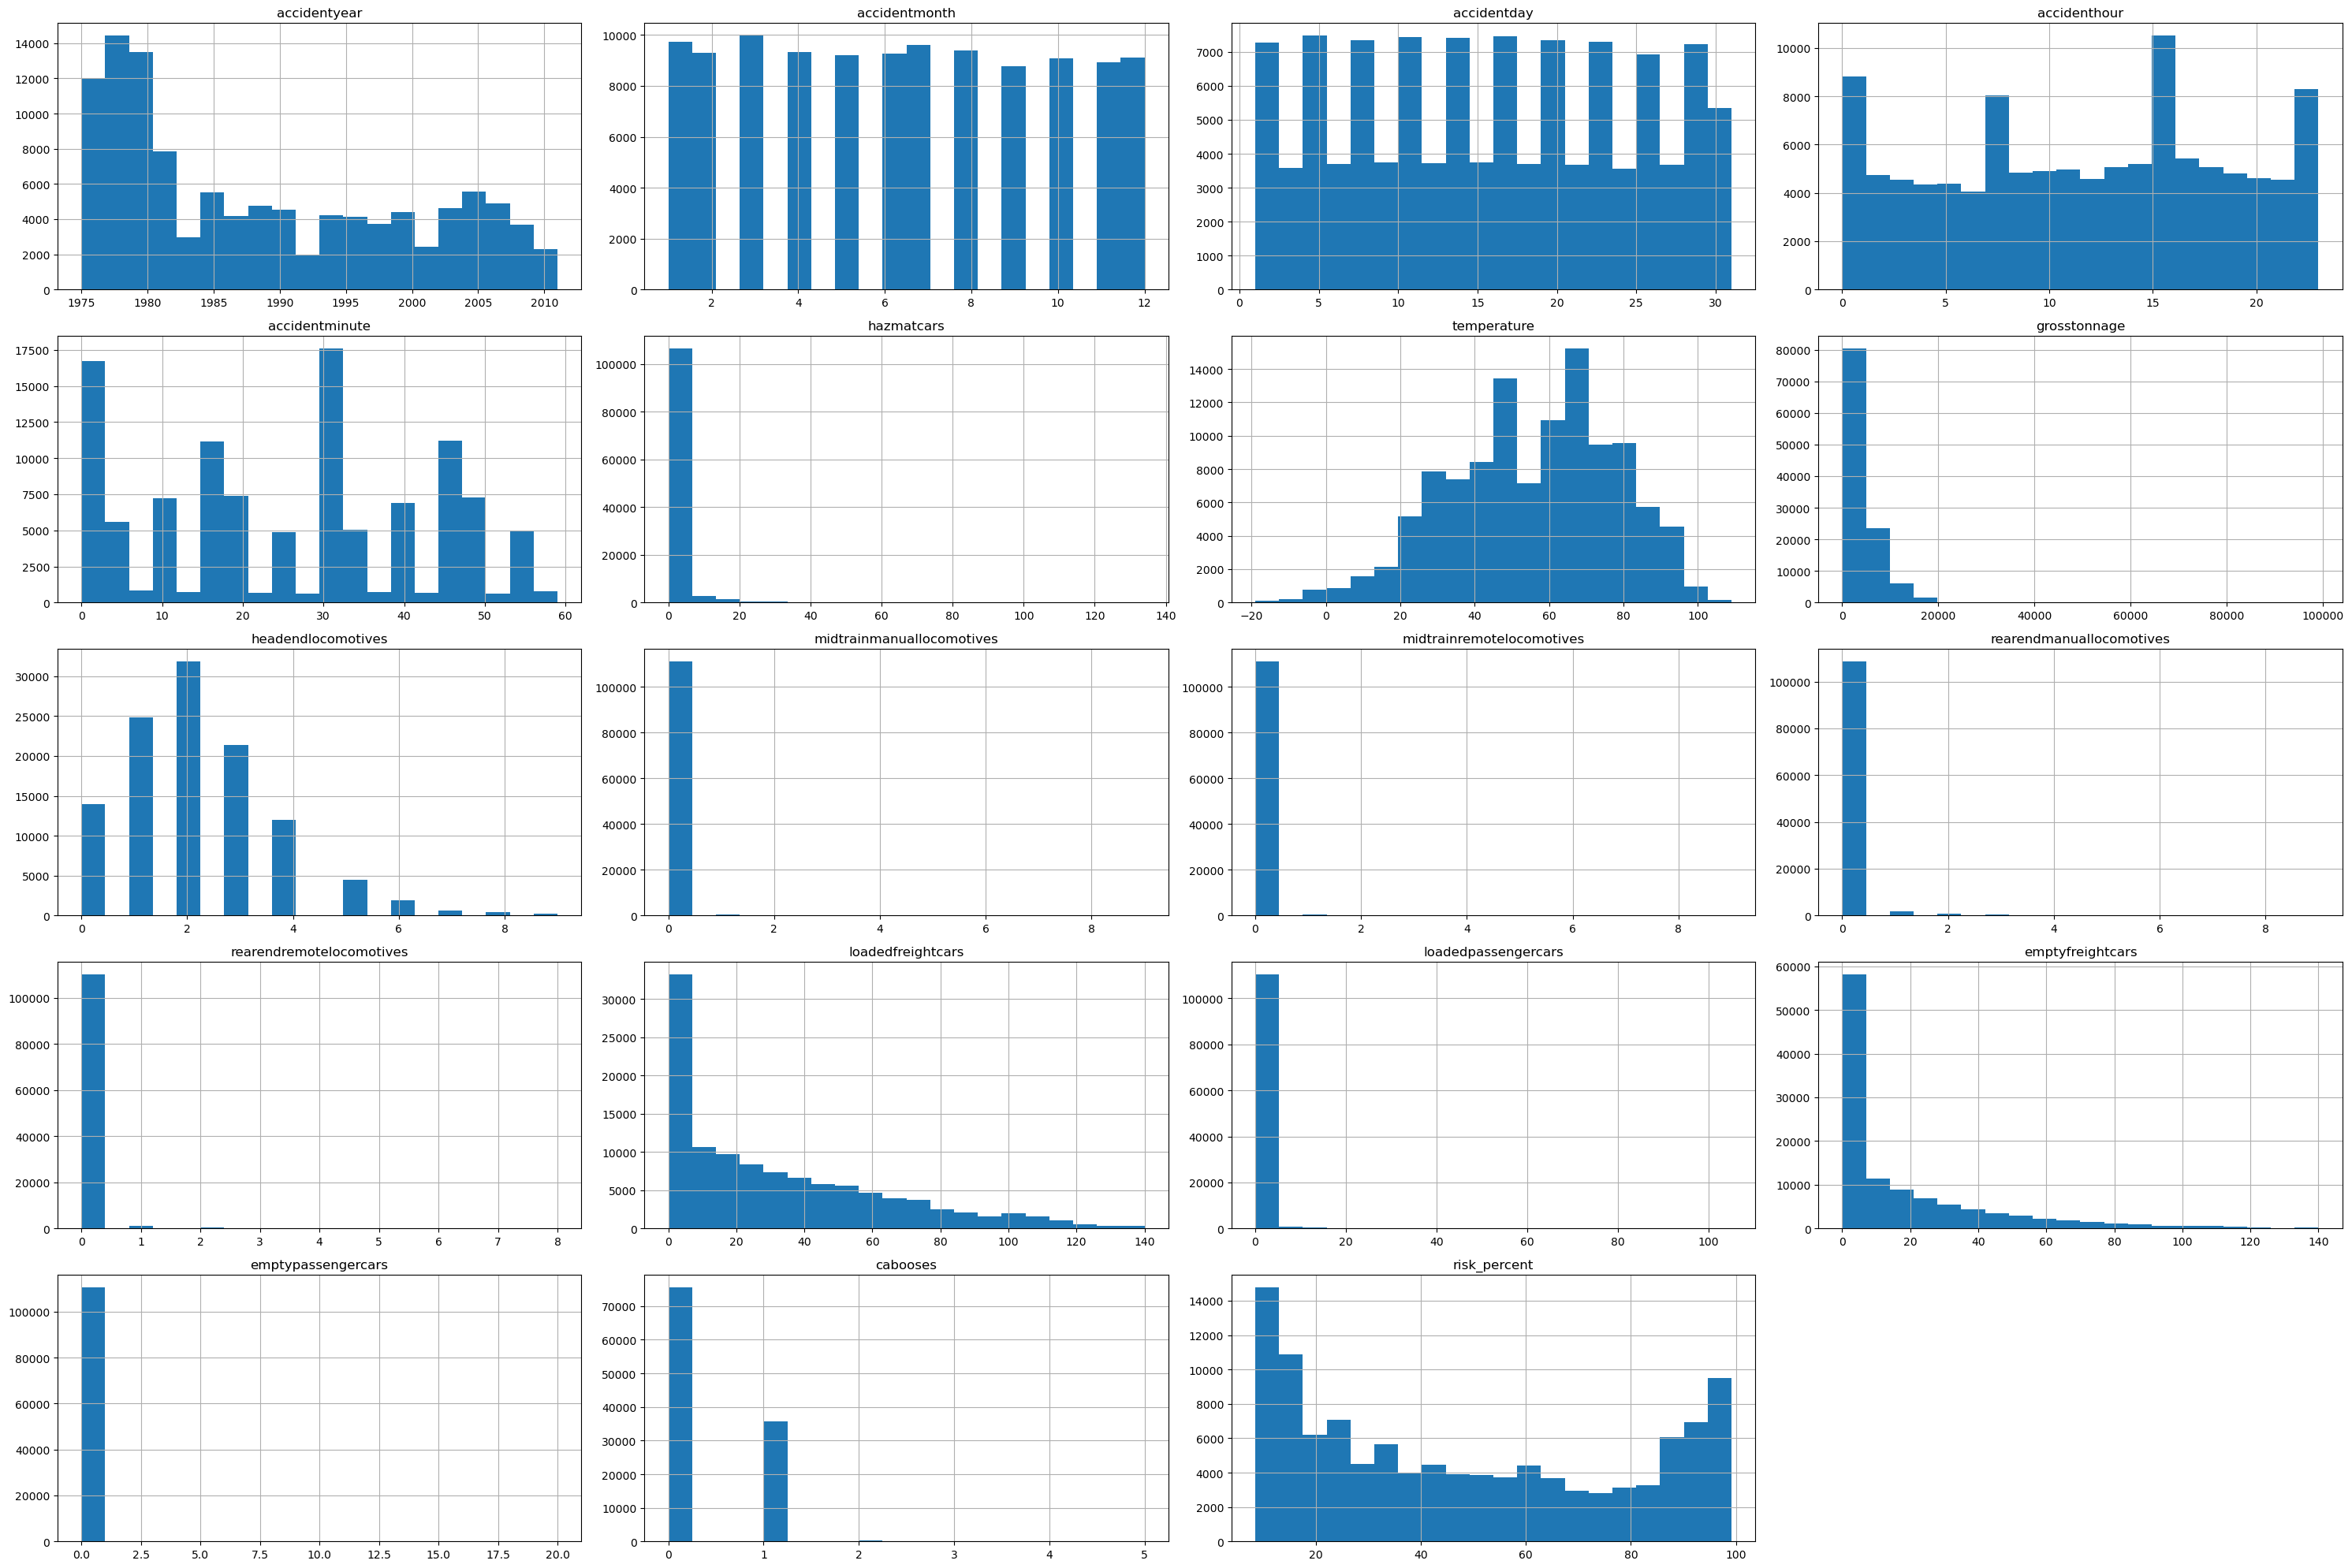

In [50]:
# Display distribution of numeric features
dist = df_train.hist(figsize=(30,20), bins = 20)
plt.tight_layout()
plt.show()

In [51]:
# Display description of numeric features
display(df_train.describe())

# Display shape of dataframe
print(f'Shape:{df_train.shape}')

,accidentyear,accidentmonth,accidentday,accidenthour,accidentminute,hazmatcars,temperature,grosstonnage,headendlocomotives,midtrainmanuallocomotives,midtrainremotelocomotives,rearendmanuallocomotives,rearendremotelocomotives,loadedfreightcars,loadedpassengercars,emptyfreightcars,emptypassengercars,cabooses,risk_percent
count,111682.000000,111682.000000,111682.000000,111682.000000,111682.000000,111682.000000,111682.000000,111682.000000,111682.000000,111682.000000,111682.000000,111682.000000,111682.000000,111682.000000,111682.000000,111682.000000,111682.000000,111682.000000,111682.000000
mean,1988.559714,6.419665,15.669159,11.684040,25.445793,1.109284,55.673976,3358.452669,2.188750,0.014855,0.014792,0.048137,0.018759,31.747721,0.171147,17.469932,0.060672,0.328898,48.287061
std,10.989920,3.452582,8.769111,6.789632,17.350210,5.042829,22.123772,4233.280766,1.523511,0.231328,0.224237,0.327619,0.178733,31.892070,1.504353,25.210155,0.689010,0.482749,30.454696
min,1975.000000,1.000000,1.000000,0.000000,0.000000,0.000000,-19.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,8.522576
25%,1979.000000,3.000000,8.000000,6.000000,10.000000,0.000000,40.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,4.000000,0.000000,0.000000,0.000000,0.000000,19.297655
50%,1985.000000,6.000000,16.000000,12.000000,29.000000,0.000000,58.000000,2080.000000,2.000000,0.000000,0.000000,0.000000,0.000000,22.000000,0.000000,5.000000,0.000000,0.000000,42.636498
75%,1998.000000,9.000000,23.000000,17.000000,40.000000,0.000000,73.000000,5420.000000,3.000000,0.000000,0.000000,0.000000,0.000000,51.000000,0.000000,26.000000,0.000000,1.000000,78.098020
max,2011.000000,12.000000,31.000000,23.000000,59.000000,134.000000,109.000000,99000.000000,9.000000,9.000000,9.000000,9.000000,8.000000,140.000000,105.000000,140.000000,20.000000,5.000000,99.131439


Shape:(111682, 32)


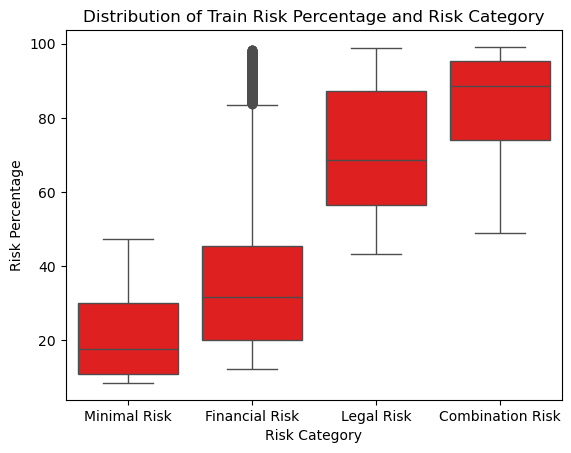

In [52]:
# Display boxplot of class category and percentage risk
sns.boxplot(data=df_train, x = 'risk_category', y = 'risk_percent', color = 'red', order = x_order)
plt.title('Distribution of Train Risk Percentage and Risk Category')
plt.xlabel('Risk Category')
plt.ylabel('Risk Percentage')
plt.show()

In [53]:
# Calculate correlation score to target variable
corr_risk_percent = df_train.corr(numeric_only = True)['risk_percent']
print(corr_risk_percent)

accidentyear                 0.044984
accidentmonth               -0.010113
accidentday                  0.000378
accidenthour                 0.007853
accidentminute               0.039089
hazmatcars                   0.161579
temperature                 -0.002623
grosstonnage                 0.258734
headendlocomotives           0.275705
midtrainmanuallocomotives    0.024417
midtrainremotelocomotives    0.008258
rearendmanuallocomotives     0.018606
rearendremotelocomotives     0.044964
loadedfreightcars            0.253605
loadedpassengercars          0.035591
emptyfreightcars             0.066546
emptypassengercars           0.053637
cabooses                     0.150451
risk_percent                 1.000000
Name: risk_percent, dtype: float64


### Test Set

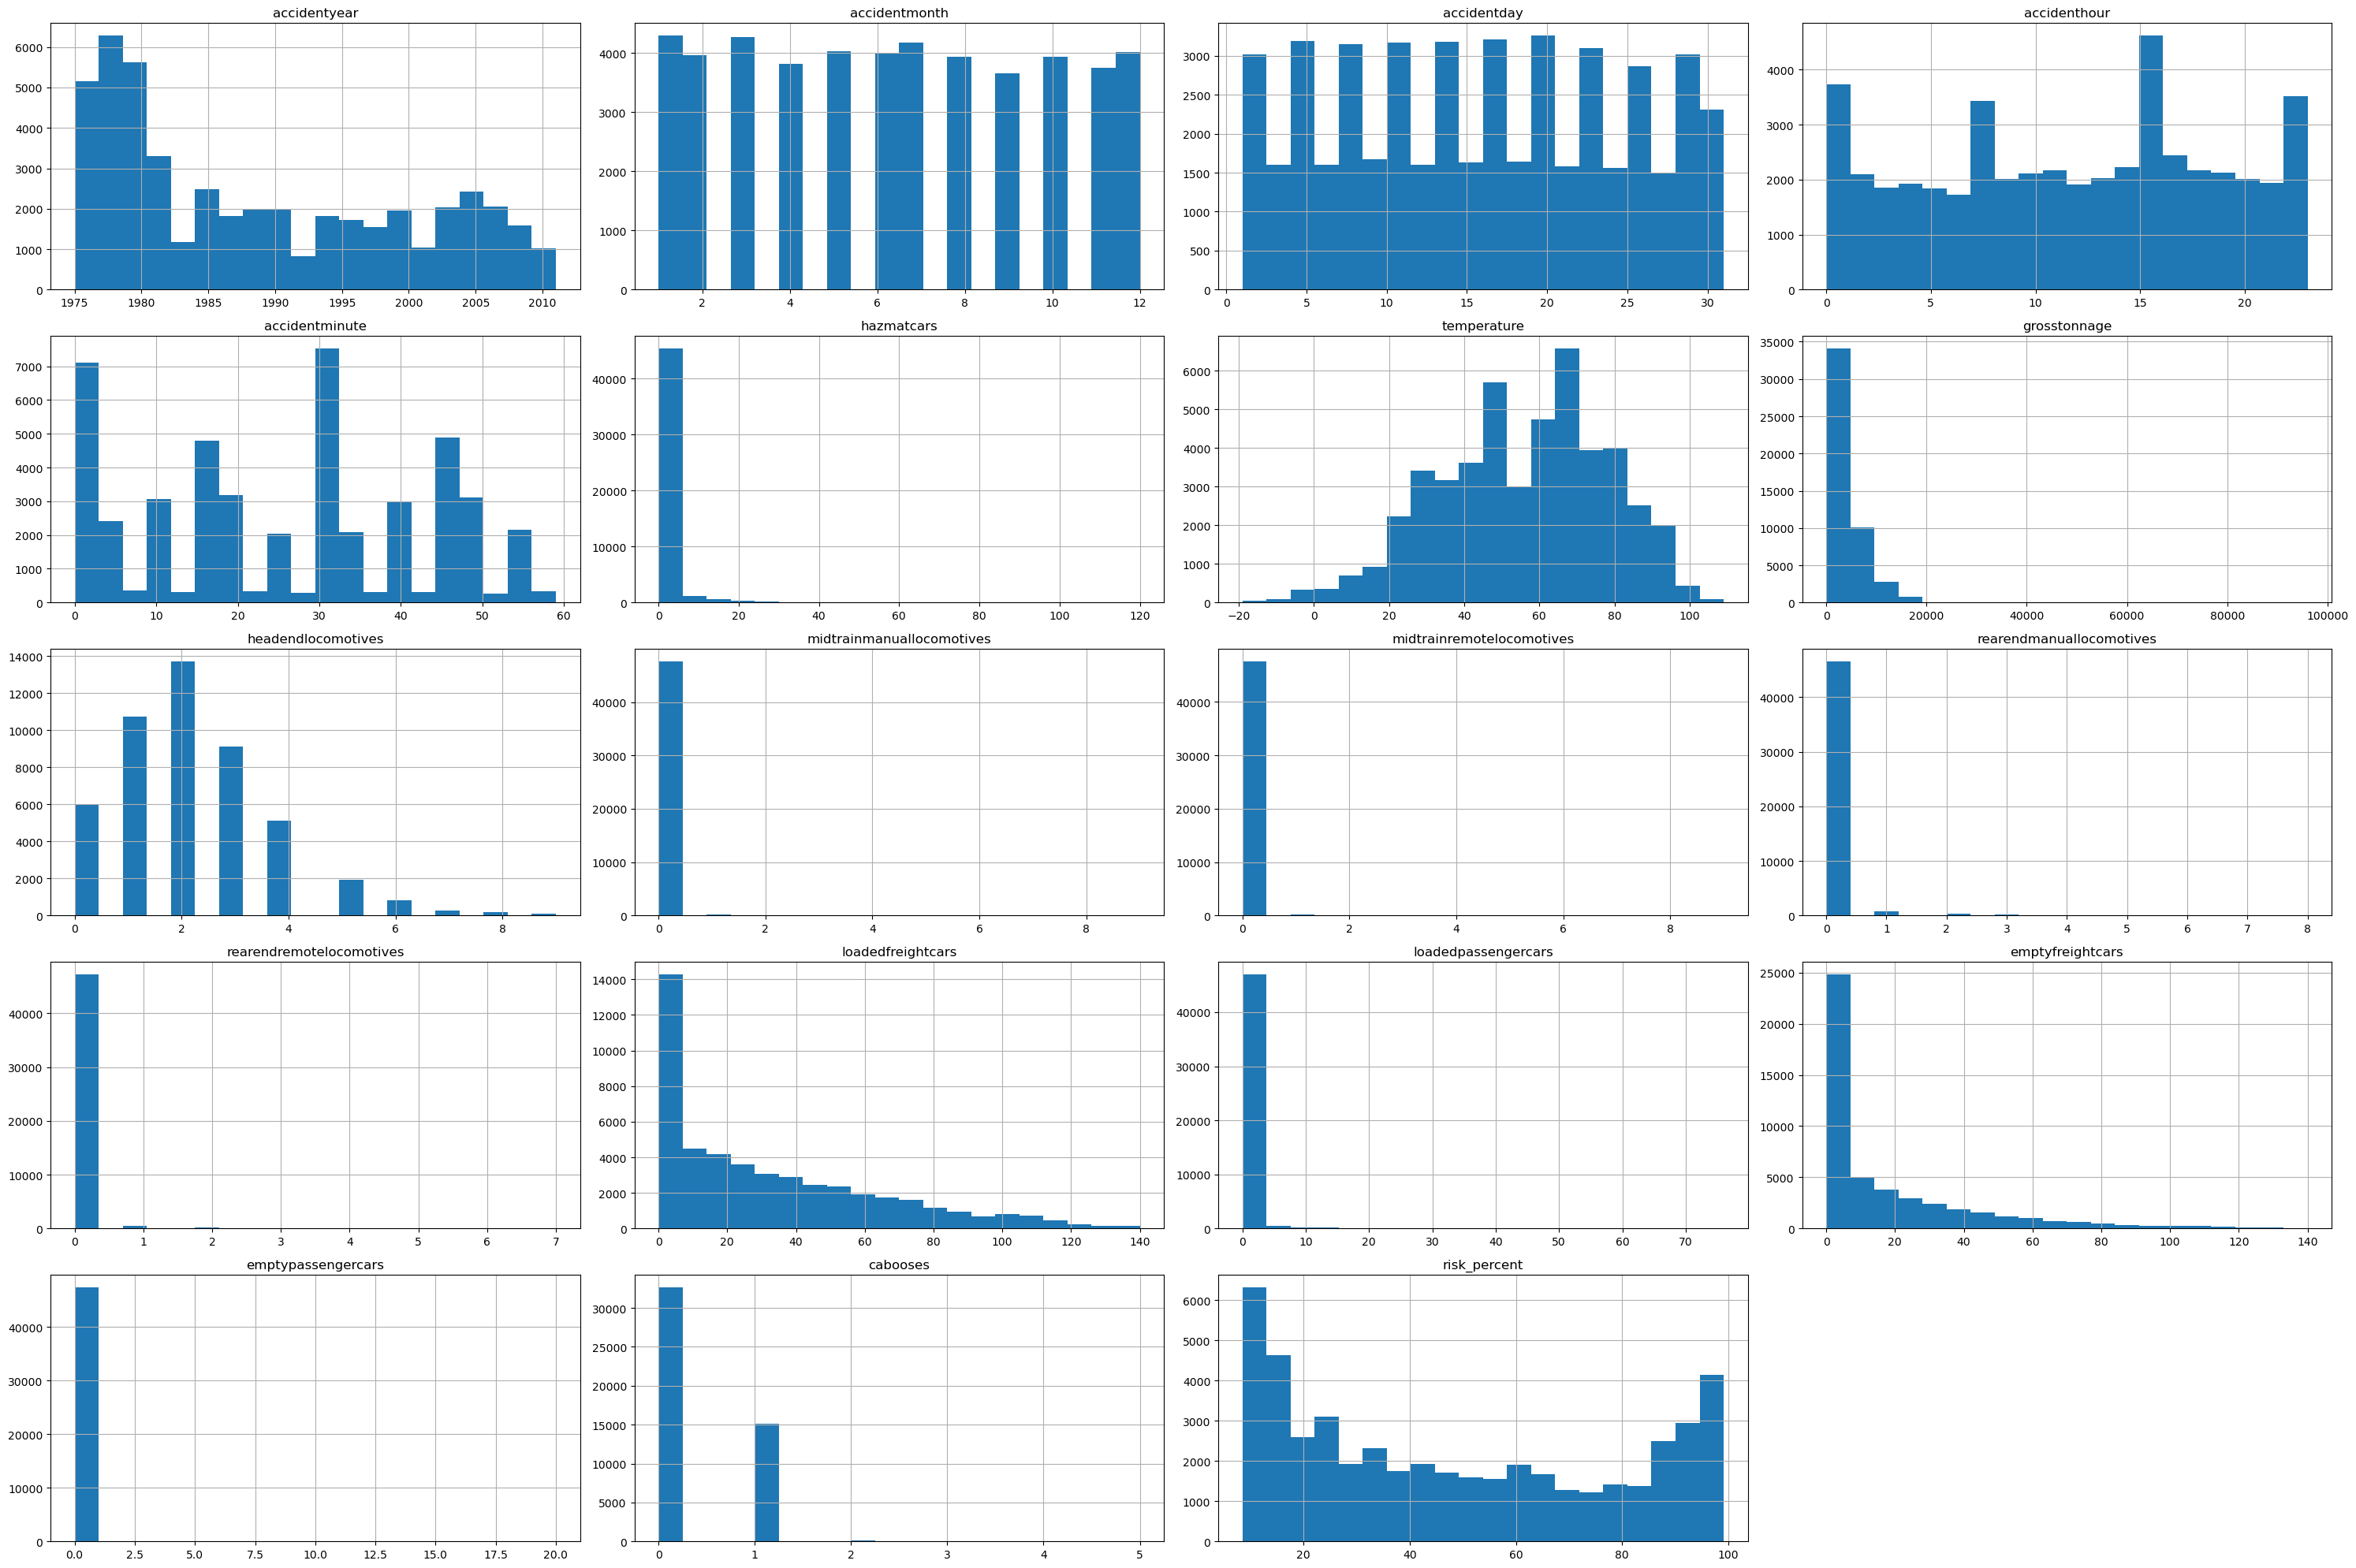

In [54]:
dist = df_test.hist(figsize=(30,20), bins = 20)
plt.tight_layout()
plt.show()

In [55]:
# Display description of numeric features
display(df_test.describe())

# Display shape of dataframe
print(f'Shape:{df_test.shape}')

,accidentyear,accidentmonth,accidentday,accidenthour,accidentminute,hazmatcars,temperature,grosstonnage,headendlocomotives,midtrainmanuallocomotives,midtrainremotelocomotives,rearendmanuallocomotives,rearendremotelocomotives,loadedfreightcars,loadedpassengercars,emptyfreightcars,emptypassengercars,cabooses,risk_percent
count,47864.000000,47864.000000,47864.000000,47864.000000,47864.000000,47864.000000,47864.000000,47864.000000,47864.000000,47864.000000,47864.000000,47864.000000,47864.000000,47864.000000,47864.000000,47864.000000,47864.000000,47864.000000,47864.000000
mean,1988.594685,6.414006,15.634443,11.713480,25.530273,1.092366,55.678046,3336.765899,2.179530,0.014499,0.015168,0.048178,0.019075,31.787774,0.186591,17.295525,0.061946,0.323040,48.366668
std,11.019739,3.464265,8.728867,6.788465,17.356278,4.953387,22.194223,4233.076130,1.518141,0.224576,0.220778,0.332228,0.176887,31.922547,1.589567,24.869789,0.683914,0.477764,30.447113
min,1975.000000,1.000000,1.000000,0.000000,0.000000,0.000000,-19.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,8.522576
25%,1979.000000,3.000000,8.000000,6.000000,10.000000,0.000000,40.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,3.000000,0.000000,0.000000,0.000000,0.000000,19.418963
50%,1985.000000,6.000000,16.000000,12.000000,30.000000,0.000000,58.000000,2000.000000,2.000000,0.000000,0.000000,0.000000,0.000000,22.000000,0.000000,5.000000,0.000000,0.000000,42.729847
75%,1999.000000,9.000000,23.000000,17.000000,40.000000,0.000000,73.000000,5400.000000,3.000000,0.000000,0.000000,0.000000,0.000000,51.000000,0.000000,26.000000,0.000000,1.000000,78.067458
max,2011.000000,12.000000,31.000000,23.000000,59.000000,120.000000,109.000000,96019.000000,9.000000,9.000000,9.000000,8.000000,7.000000,140.000000,76.000000,140.000000,20.000000,5.000000,99.107825


Shape:(47864, 32)


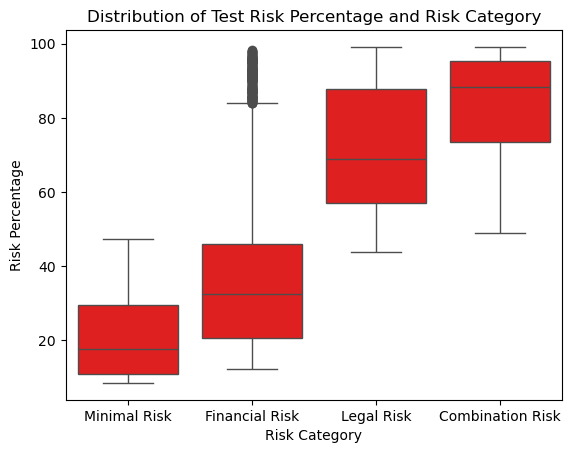

In [56]:
# Display boxplot of class category and percentage risk
sns.boxplot(data=df_test, x = 'risk_category', y = 'risk_percent', color = 'red', order = x_order)
plt.title('Distribution of Test Risk Percentage and Risk Category')
plt.xlabel('Risk Category')
plt.ylabel('Risk Percentage')
plt.show()

## Seperating Train/Test/Target Variables

In [57]:
# KNN Target Variable
y_train_knn = df_train['risk_category']
y_test_knn = df_test['risk_category']

# Linear Regression Variable
y_train_lin = df_train['risk_percent']
y_test_lin = df_test['risk_percent']

# X_train and X_test
X_train = df_train.drop(columns=['risk_category','risk_percent'])
X_test = df_test.drop(columns=['risk_category','risk_percent'])

## Preparing Dataframe for Modeling

#### Frequency Calculation

**Because some features have numerous categorical values, using a frequency count instead of one-hot encoding reduces dimensionality. It does have limitations, as two similar frequency scores cannot be distinguished from one another.**

In [58]:
# Set features used for frequency
df_freq_encod = ['reportingrailroadcode',
                 'maintenancerailroadcode',
                 'stateabbreviation',
                 'district',
                 'division',
                 'countyname']

# Claude AI was used to help trouble shoot coding logic to avoid data leaking 
for i in df_freq_encod:
    frequency = X_train[i].value_counts(normalize=True) # Value count as a percentage per feature column
    X_train[i + 'fq'] = X_train[i].map(frequency) # Replace category value with it frequency value in training
    X_test[i + 'fq'] = X_test[i].map(frequency) # Follows the same principle, but in testing
    X_test[i + 'fq'] = X_test[i + 'fq'].fillna(0) # If not present, fill with 0

X_train = X_train.drop(columns = df_freq_encod) # Drop redundent columns
X_test = X_test.drop(columns = df_freq_encod) # Drop redundent columns

In [59]:
X_train.head(3)

,accidentyear,accidentmonth,accidentday,accidenthour,accidentminute,accidenttype,hazmatcars,temperature,visibilitycode,visibility,weatherconditioncode,tracktype,grosstonnage,passengerstransported,headendlocomotives,midtrainmanuallocomotives,midtrainremotelocomotives,rearendmanuallocomotives,rearendremotelocomotives,loadedfreightcars,loadedpassengercars,emptyfreightcars,emptypassengercars,cabooses,reportingrailroadcodefq,maintenancerailroadcodefq,stateabbreviationfq,districtfq,divisionfq,countynamefq
121524,1981,11,13,19.0,40.0,Derailment,1,50,4.0,Dark,1.0,Yard,2140,No,2,0,0,0,0,16,0,18,0,1,0.019233,0.018785,0.021436,0.150579,0.002982,0.005632
133059,1979,4,1,12.0,50.0,Derailment,0,40,2.0,Day,2.0,Main,9032,No,4,0,0,0,0,68,0,2,0,1,0.014219,0.014595,0.037249,0.158262,0.017398,0.002641
15257,1984,5,7,13.0,30.0,Side collision,0,50,2.0,Day,2.0,Yard,0,No,1,0,0,0,0,0,0,7,0,0,0.045970,0.044716,0.037249,0.158262,0.017398,0.000734


In [60]:
X_test.head(3)

,accidentyear,accidentmonth,accidentday,accidenthour,accidentminute,accidenttype,hazmatcars,temperature,visibilitycode,visibility,weatherconditioncode,tracktype,grosstonnage,passengerstransported,headendlocomotives,midtrainmanuallocomotives,midtrainremotelocomotives,rearendmanuallocomotives,rearendremotelocomotives,loadedfreightcars,loadedpassengercars,emptyfreightcars,emptypassengercars,cabooses,reportingrailroadcodefq,maintenancerailroadcodefq,stateabbreviationfq,districtfq,divisionfq,countynamefq
146877,1979,9,20,14.0,45.0,Derailment,0,80,2.0,Day,1.0,Main,4909,No,2,0,0,0,0,51,0,15,0,0,0.016207,0.015866,0.027131,0.158262,0.008820,0.000143
129942,1980,6,19,11.0,15.0,Rear end collision,0,63,2.0,Day,3.0,Yard,0,No,1,0,0,0,0,17,0,0,0,0,0.126806,0.127030,0.030014,0.158262,0.014685,0.011121
182668,1976,12,5,2.0,0.0,Derailment,0,19,4.0,Dark,2.0,Siding,4939,No,6,0,0,0,0,38,0,59,0,1,0.022877,0.022242,0.037249,0.158262,0.010718,0.001271


### One Hot Encoding

In [61]:
categorical_cols = X_train.select_dtypes(include=['object']).columns # Subset categorical features
encode = OneHotEncoder(sparse_output=False) # Implement One Hot Encoding
train_encode = encode.fit_transform(X_train[categorical_cols]) # Fit on train
test_encode = encode.transform(X_test[categorical_cols]) # Implement on test

# Created an array. Claude AI was used to help trouble shoot how to return a dataframe. 
train_encode_df = pd.DataFrame(train_encode,columns=encode.get_feature_names_out(categorical_cols),index=X_train.index)
test_encode_df = pd.DataFrame(test_encode,columns=encode.get_feature_names_out(categorical_cols),index=X_test.index)

X_train=X_train.drop(columns=categorical_cols).join(train_encode_df)
X_test=X_test.drop(columns=categorical_cols).join(test_encode_df)

In [62]:
X_train.head(3)

,accidentyear,accidentmonth,accidentday,accidenthour,accidentminute,hazmatcars,temperature,grosstonnage,headendlocomotives,midtrainmanuallocomotives,midtrainremotelocomotives,rearendmanuallocomotives,rearendremotelocomotives,loadedfreightcars,loadedpassengercars,emptyfreightcars,emptypassengercars,cabooses,reportingrailroadcodefq,maintenancerailroadcodefq,stateabbreviationfq,districtfq,divisionfq,countynamefq,accidenttype_Broken train collision,accidenttype_Derailment,accidenttype_Explosion-detonation,accidenttype_Fire/violent rupture,accidenttype_Head on collision,accidenttype_Hwy-rail crossing,accidenttype_Obstruction,accidenttype_Other impacts,accidenttype_RR grade crossing,accidenttype_Raking collision,accidenttype_Rear end collision,accidenttype_Side collision,visibilitycode_1.0,visibilitycode_2.0,visibilitycode_3.0,visibilitycode_4.0,visibility_Dark,visibility_Dawn,visibility_Day,visibility_Dusk,weatherconditioncode_1.0,weatherconditioncode_2.0,weatherconditioncode_3.0,weatherconditioncode_4.0,weatherconditioncode_5.0,weatherconditioncode_6.0,weatherconditioncode_nan,tracktype_Industry,tracktype_Main,tracktype_Siding,tracktype_Yard,passengerstransported_No,passengerstransported_Unknown,passengerstransported_Yes
121524,1981,11,13,19.0,40.0,1,50,2140,2,0,0,0,0,16,0,18,0,1,0.019233,0.018785,0.021436,0.150579,0.002982,0.005632,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0
133059,1979,4,1,12.0,50.0,0,40,9032,4,0,0,0,0,68,0,2,0,1,0.014219,0.014595,0.037249,0.158262,0.017398,0.002641,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0
15257,1984,5,7,13.0,30.0,0,50,0,1,0,0,0,0,0,0,7,0,0,0.045970,0.044716,0.037249,0.158262,0.017398,0.000734,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0


In [63]:
X_test.head(3)

,accidentyear,accidentmonth,accidentday,accidenthour,accidentminute,hazmatcars,temperature,grosstonnage,headendlocomotives,midtrainmanuallocomotives,midtrainremotelocomotives,rearendmanuallocomotives,rearendremotelocomotives,loadedfreightcars,loadedpassengercars,emptyfreightcars,emptypassengercars,cabooses,reportingrailroadcodefq,maintenancerailroadcodefq,stateabbreviationfq,districtfq,divisionfq,countynamefq,accidenttype_Broken train collision,accidenttype_Derailment,accidenttype_Explosion-detonation,accidenttype_Fire/violent rupture,accidenttype_Head on collision,accidenttype_Hwy-rail crossing,accidenttype_Obstruction,accidenttype_Other impacts,accidenttype_RR grade crossing,accidenttype_Raking collision,accidenttype_Rear end collision,accidenttype_Side collision,visibilitycode_1.0,visibilitycode_2.0,visibilitycode_3.0,visibilitycode_4.0,visibility_Dark,visibility_Dawn,visibility_Day,visibility_Dusk,weatherconditioncode_1.0,weatherconditioncode_2.0,weatherconditioncode_3.0,weatherconditioncode_4.0,weatherconditioncode_5.0,weatherconditioncode_6.0,weatherconditioncode_nan,tracktype_Industry,tracktype_Main,tracktype_Siding,tracktype_Yard,passengerstransported_No,passengerstransported_Unknown,passengerstransported_Yes
146877,1979,9,20,14.0,45.0,0,80,4909,2,0,0,0,0,51,0,15,0,0,0.016207,0.015866,0.027131,0.158262,0.008820,0.000143,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0
129942,1980,6,19,11.0,15.0,0,63,0,1,0,0,0,0,17,0,0,0,0,0.126806,0.127030,0.030014,0.158262,0.014685,0.011121,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0
182668,1976,12,5,2.0,0.0,0,19,4939,6,0,0,0,0,38,0,59,0,1,0.022877,0.022242,0.037249,0.158262,0.010718,0.001271,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0


### Standard Scaler

**Month, day, hour, and minute were all scaled. Might need to revisit as these columns are circular. Scaling them break their logic (After 12 comes 1, not 13).**

In [64]:
continuous_cols = ['accidentyear','accidentmonth','accidentday','accidenthour','accidentminute','hazmatcars','temperature','grosstonnage','headendlocomotives','midtrainmanuallocomotives','midtrainremotelocomotives',
                   'rearendmanuallocomotives','rearendremotelocomotives','loadedfreightcars','loadedpassengercars','emptyfreightcars','emptypassengercars',
                   'cabooses']

scaler = StandardScaler() # Implement Standard Scaler
X_train[continuous_cols] = scaler.fit_transform(X_train[continuous_cols]) # Fit scale on train
X_test[continuous_cols] = scaler.transform(X_test[continuous_cols]) # Implement on test

In [65]:
X_train.head(3)

,accidentyear,accidentmonth,accidentday,accidenthour,accidentminute,hazmatcars,temperature,grosstonnage,headendlocomotives,midtrainmanuallocomotives,midtrainremotelocomotives,rearendmanuallocomotives,rearendremotelocomotives,loadedfreightcars,loadedpassengercars,emptyfreightcars,emptypassengercars,cabooses,reportingrailroadcodefq,maintenancerailroadcodefq,stateabbreviationfq,districtfq,divisionfq,countynamefq,accidenttype_Broken train collision,accidenttype_Derailment,accidenttype_Explosion-detonation,accidenttype_Fire/violent rupture,accidenttype_Head on collision,accidenttype_Hwy-rail crossing,accidenttype_Obstruction,accidenttype_Other impacts,accidenttype_RR grade crossing,accidenttype_Raking collision,accidenttype_Rear end collision,accidenttype_Side collision,visibilitycode_1.0,visibilitycode_2.0,visibilitycode_3.0,visibilitycode_4.0,visibility_Dark,visibility_Dawn,visibility_Day,visibility_Dusk,weatherconditioncode_1.0,weatherconditioncode_2.0,weatherconditioncode_3.0,weatherconditioncode_4.0,weatherconditioncode_5.0,weatherconditioncode_6.0,weatherconditioncode_nan,tracktype_Industry,tracktype_Main,tracktype_Siding,tracktype_Yard,passengerstransported_No,passengerstransported_Unknown,passengerstransported_Yes
121524,-0.687880,1.326646,-0.304383,1.077524,0.838853,-0.021671,-0.256466,-0.287828,-0.123892,-0.064215,-0.065966,-0.146929,-0.104954,-0.493784,-0.113768,0.021026,-0.088058,1.390173,0.019233,0.018785,0.021436,0.150579,0.002982,0.005632,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0
133059,-0.869866,-0.700831,-1.672829,0.046536,1.415217,-0.219973,-0.708471,1.340231,1.188871,-0.064215,-0.065966,-0.146929,-0.104954,1.136723,-0.113768,-0.613642,-0.088058,1.390173,0.014219,0.014595,0.037249,0.158262,0.017398,0.002641,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0
15257,-0.414902,-0.411191,-0.988606,0.193820,0.262488,-0.219973,-0.256466,-0.793349,-0.780274,-0.064215,-0.065966,-0.146929,-0.104954,-0.995478,-0.113768,-0.415308,-0.088058,-0.681305,0.045970,0.044716,0.037249,0.158262,0.017398,0.000734,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0


In [66]:
X_test.head(3)

,accidentyear,accidentmonth,accidentday,accidenthour,accidentminute,hazmatcars,temperature,grosstonnage,headendlocomotives,midtrainmanuallocomotives,midtrainremotelocomotives,rearendmanuallocomotives,rearendremotelocomotives,loadedfreightcars,loadedpassengercars,emptyfreightcars,emptypassengercars,cabooses,reportingrailroadcodefq,maintenancerailroadcodefq,stateabbreviationfq,districtfq,divisionfq,countynamefq,accidenttype_Broken train collision,accidenttype_Derailment,accidenttype_Explosion-detonation,accidenttype_Fire/violent rupture,accidenttype_Head on collision,accidenttype_Hwy-rail crossing,accidenttype_Obstruction,accidenttype_Other impacts,accidenttype_RR grade crossing,accidenttype_Raking collision,accidenttype_Rear end collision,accidenttype_Side collision,visibilitycode_1.0,visibilitycode_2.0,visibilitycode_3.0,visibilitycode_4.0,visibility_Dark,visibility_Dawn,visibility_Day,visibility_Dusk,weatherconditioncode_1.0,weatherconditioncode_2.0,weatherconditioncode_3.0,weatherconditioncode_4.0,weatherconditioncode_5.0,weatherconditioncode_6.0,weatherconditioncode_nan,tracktype_Industry,tracktype_Main,tracktype_Siding,tracktype_Yard,passengerstransported_No,passengerstransported_Unknown,passengerstransported_Yes
146877,-0.869866,0.747367,0.493877,0.341104,1.127035,-0.219973,1.099547,0.366277,-0.123892,-0.064215,-0.065966,-0.146929,-0.104954,0.603672,-0.113768,-0.097974,-0.088058,-0.681305,0.016207,0.015866,0.027131,0.158262,0.008820,0.000143,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0
129942,-0.778873,-0.121552,0.379840,-0.100748,-0.602058,-0.219973,0.331140,-0.793349,-0.780274,-0.064215,-0.065966,-0.146929,-0.104954,-0.462428,-0.113768,-0.692975,-0.088058,-0.681305,0.126806,0.127030,0.030014,0.158262,0.014685,0.011121,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0
182668,-1.142845,1.616286,-1.216680,-1.426305,-1.466605,-0.219973,-1.657680,0.373364,2.501634,-0.064215,-0.065966,-0.146929,-0.104954,0.196046,-0.113768,1.647362,-0.088058,1.390173,0.022877,0.022242,0.037249,0.158262,0.010718,0.001271,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0


## Model Testing

### Linear Modeling

**I implemented a Decision Tree Regression to calculate feature importance towards the target variable 'risk_percent.' Based on the output, the most important feature was 'accidenttype_Derailment' in predicting risk, with a score of 0.097. The top-performing score is low due to the number of features, summing up to 1. It is also important that this was implemented after One Hot Encoding, so to determine specific features' important, you will need to sum up their scores together.**

In [67]:
# Implement Decision Tree Regression
model = DecisionTreeRegressor(random_state=42)
model.fit(X_train, y_train_lin)

importance = model.feature_importances_
print(pd.DataFrame(importance, columns = ["Score"], index = X_train.columns).sort_values(by="Score", ascending = False))

                                        Score
accidenttype_Derailment              0.097035
hazmatcars                           0.063200
grosstonnage                         0.059032
loadedfreightcars                    0.056790
countynamefq                         0.054945
temperature                          0.051606
accidentday                          0.050321
accidentyear                         0.048238
emptyfreightcars                     0.047839
accidenthour                         0.046218
divisionfq                           0.044753
accidentminute                       0.044258
headendlocomotives                   0.038176
stateabbreviationfq                  0.034521
accidentmonth                        0.033942
tracktype_Main                       0.029969
maintenancerailroadcodefq            0.026217
reportingrailroadcodefq              0.025514
accidenttype_Hwy-rail crossing       0.022512
districtfq                           0.019163
emptypassengercars                

**A simple Linear Regression model was implemented as the base level. The returning train RMSE was 26.72, and the test RMSE was 26.67, with a 0.05 gap between. The gap is small, hinting that it was not overfitting. The problem comes from the high RMSE score, suggesting that the model deviates from the actual value by over 25. With both values being off by a large margin, could hint at underfitting**

In [68]:
lin = LinearRegression()
lin.fit(X_train, y_train_lin)

pred_train_lin=lin.predict(X_train)
pred_test_lin=lin.predict(X_test)

rmse_train = np.sqrt(mean_squared_error(y_train_lin, pred_train_lin))
rmse_test = np.sqrt(mean_squared_error(y_test_lin, pred_test_lin))

print(f"  Train RMSE: {rmse_train:.4f}")
print(f"  Test  RMSE: {rmse_test:.4f}")
print(f"  Gap:        {rmse_test - rmse_train:.4f}")

  Train RMSE: 26.7250
  Test  RMSE: 26.6747
  Gap:        -0.0503


### KNN Model

**Before KNN, I wanted to determine the feature importance from a classification perspective. I implemented a Decision Tree Classifier and found that the most influential feature was 'accidentyear' at 0.075. This is a little concerning, as time being the dominant feature could hint at a class imbalance over the years. Would require an investigation of categories over time. Strongest performing class was Minimal Risk with a precision score of 0.61. SMOTE helped increase Finanical and Legal risk score, but not by a significant margin.**

In [69]:
model = DecisionTreeClassifier(random_state=42)
model.fit(X_train, y_train_knn)

importance = model.feature_importances_
print(pd.DataFrame(importance, columns = ["Score"], index = X_train.columns).sort_values(by="Score", ascending = False))

                                        Score
accidentyear                         0.076075
countynamefq                         0.067036
temperature                          0.066866
loadedfreightcars                    0.064098
accidentday                          0.061570
grosstonnage                         0.061263
emptyfreightcars                     0.055687
accidenthour                         0.054087
accidentminute                       0.050655
divisionfq                           0.049648
stateabbreviationfq                  0.044215
accidentmonth                        0.043884
tracktype_Main                       0.032687
headendlocomotives                   0.032604
maintenancerailroadcodefq            0.031822
reportingrailroadcodefq              0.030615
hazmatcars                           0.029611
accidenttype_Derailment              0.026581
districtfq                           0.022908
weatherconditioncode_1.0             0.007894
weatherconditioncode_2.0          

In [70]:
# Implement class imbalance correction
sm = SMOTE(random_state=42)
X_train_res, y_train_knn_res = sm.fit_resample(X_train, y_train_knn)

# Display Results
print("Before:", Counter(y_train_knn))
print("After:", Counter(y_train_knn_res))

Before: Counter({'Minimal Risk': 46290, 'Combination Risk': 25261, 'Legal Risk': 24976, 'Financial Risk': 15155})
After: Counter({'Legal Risk': 46290, 'Minimal Risk': 46290, 'Combination Risk': 46290, 'Financial Risk': 46290})


In [71]:
knn = KNeighborsClassifier(n_neighbors=3)
knn.fit(X_train_res, y_train_knn_res)

pred_train_knn=knn.predict(X_train_res)
pred_test_knn=knn.predict(X_test)

print("Classification Report:", classification_report(y_test_knn, pred_test_knn))

Classification Report:                   precision    recall  f1-score   support

Combination Risk       0.37      0.47      0.41     10774
  Financial Risk       0.23      0.34      0.27      6715
      Legal Risk       0.32      0.34      0.33     10652
    Minimal Risk       0.60      0.38      0.46     19723

        accuracy                           0.39     47864
       macro avg       0.38      0.38      0.37     47864
    weighted avg       0.43      0.39      0.40     47864



## Next Steps

1) Revisit features used for engineering target variable. Consider removing features or finding a different method of assigning class weights.
2) Explore methods for improving the models (Polynomial Function, PCA, etc.)
3) Determine optimal hyperparameters and perform a grid search. Might consider also implementing Elastic Net model to catch multicollinearity and perform a form of feature selection.

## Reference Sources

https://www.geeksforgeeks.org/python/how-to-standardize-data-in-a-pandas-dataframe/
https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.PowerTransformer.html
https://www.datacamp.com/tutorial/k-nearest-neighbor-classification-scikit-learn
https://www.codecademy.com/article/linear-regression-with-scikit-learn-a-step-by-step-guide-using-python
https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LinearRegression.html
https://www.geeksforgeeks.org/machine-learning/smote-for-imbalanced-classification-with-python/
https://beyondknowledgeinnovation.ai/feature-importance-in-decision-tree/
https://scikit-learn.org/stable/auto_examples/ensemble/plot_forest_importances.html
https://www.geeksforgeeks.org/engineering-mathematics/cumulative-distribution-function/
https://www.geeksforgeeks.org/machine-learning/ml-one-hot-encoding/
https://www.geeksforgeeks.org/machine-learning/understanding-feature-importance-and-visualization-of-tree-models/#1-decision-tree-feature-importance
https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.probplot.html